In [1]:
# header for current kernel
from pyCHX.chx_packages import *
plt.rcParams.update({'figure.max_open_warning': 0})
plt.rcParams.update({ 'image.origin': 'lower'   })
plt.rcParams.update({ 'image.interpolation': 'none'   })
import matplotlib.patches as mpatches
from copy import deepcopy
from scipy.signal import argrelmax
import scipy.stats as stats
from scipy.ndimage import convolve1d
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
from scipy.optimize import fsolve
from heapq import nsmallest, nlargest
import random

import pyFAI
from pyFAI import geometryRefinement
from pyFAI.method_registry import Method,IntegrationMethod

import tqdm

import sys
sys.path.insert(0, "/nsls2/data/chx/shared/CHX_Software/packages/standard_functions/")
sys.path.insert(0, "/nsls2/data/chx/shared/CHX_Software/packages/waxs_auto_processing/")
sys.path.insert(0, "/nsls2/data/chx/shared/CHX_Software/packages/archiver_setup/")
sys.path.insert(0, "/nsls2/data/chx/shared/CHX_Software/packages/Auto_Analysis_Functions/")
from standard_functions import *
from waxs_auto_processing import split_array,waxs_fit_setup
from archiver_setup import *
from Auto_Analysis_Functions import *
%run /nsls2/data/chx/shared/CHX_Software/packages/environment_management/chx_analysis_setup_test_pyCHX.ipynb


Tiled version 0.1.0a120
/nsls2/conda/envs/2024-2.0-py311-tiled/lib/python3.11/site-packages/databroker/v1.py:72: UserWarning: In databroker 2.x, there are separate notions of 'server' and 'client', and register_handler(...) has no effect on the client. Likely this is being done for you on the server side, so you should not worry about this message unless you encounter trouble loading large array data.
  warnings.warn(


successfully imported CHX channel archiver and related functions
running on: jupyter_hub   environment: standard

setting '_base_path_' as /nsls2/data/chx/legacy/analysis/
setting '_mask_path_' as /nsls2/data/chx/shared/CHX_Setup/Detector_masks/



Tiled version 0.1.0a120
INFO:tiled.server.app:Tiled version 0.1.0a120
/nsls2/conda/envs/2024-2.0-py311-tiled/lib/python3.11/site-packages/databroker/v1.py:72: UserWarning: In databroker 2.x, there are separate notions of 'server' and 'client', and register_handler(...) has no effect on the client. Likely this is being done for you on the server side, so you should not worry about this message unless you encounter trouble loading large array data.
  warnings.warn(


Re-imported pyCHX from /nsls2/data/chx/shared/CHX_Software/packages/pyCHX/
Re-imported chx_compress from /nsls2/data/chx/shared/CHX_Software/packages/pyCHX/chx_compress.py

environment dependent settings and patches:
using "%matplotlib inline" for plotting


### Specify dataset to load

In [2]:
user = 'lwiegart' # this is the user [PI] specified during data acquisition
analyst = 'lwiegart' # this determines in which directory the output data will be saved
cycle = '2024_2'

# silver behenate calibration (list should contain only one scan_id or uid)
calibration = 149555 # WAXS detector position optimized for polypropylene sample
# data (can only handle one dataset in list yet)
scan_list =  [149996] # 5 wt% Si as a test
scan_list =  [150039] # 5 wt% Si as a test
scan_list =  [150043] # 5 wt% Si as a test
scan_list =  [150197] # 5 wt% Si 100C 0.07 -> this data has been used to develop the in-situ crystalliztion code
scan_list = [149943] # according to google sheet: crystallization happening between first and second dataset
#scan_list = [149947] # second ('ex-situ') WAXS dataset
# scan_list = [149872] # platform height =.25
#scan_list = [149893] # platform height = .4 # all crystalline, but incorrectly classified???
#scan_list = [149592] # this doesn't get picked up as in-situ crystallization... 
scan_list = [149881] # looking for more split 2nd peaks in 95wt% HOMO-5wt% PPMA...


### Control Data Processing

In [3]:
plotting=True # live plotting of fits (True / False)
create_pdf_report = True

inpainting = True  # if True: using pyFai to fill detector gaps when creating phi-map
use_centrosymmetry = True # if True: use centro-symmetry to 'recover' some missing data in phi-cuts

### papermill inserts in cell below

In [4]:
# Parameters
analyst = "lwiegart"
user = "lwiegart"
cycle = "2024_2"
#scan_list = ["622b042c-8f01-4ceb-a59c-1efa694dbc0c"]
calibration = 149555
plotting = True


In [5]:
result_dir = '%s%s/%s/%s/'%(_base_path_,cycle,analyst,'Results')
(tmp,c_uid)=get_uid_list([calibration],user=user,cycle=cycle,uid_length=8,verbose=True)
cfilepath=result_dir+'Pilatus_800k_calibration_uid_%s.pkl'%c_uid[0]
print('loading calibration data from: ',cfilepath)
(scan_list,uid_list)=get_uid_list(scan_list,user=user,cycle=cycle,uid_length=8,verbose=True)

r=db[uid_list[0]];uid_full=r['start']['uid']
result_dir_full=result_dir+'%s/'%(uid_full)
os.makedirs(result_dir_full, exist_ok=True)
pdf_dict={}
if create_pdf_report:
    pdf_fn='waxs_analysis_uid=%s.pdf'%uid_full
    print('PDF report %s will be created'%pdf_fn)
print('created directory: %s for output.'%(result_dir+'%s/'%(uid_full)))

# don't plot every image when fitting IF the notbook is run by papermill
try:
    if time.time() - insert_timestamp <20: # insert_timestamp (from papermill) exists and is recent -> this run is by pm
        plotting = False # switch live plotting off for pm runs
        print('notebook is being run by papermill -> switching live plotting off')
except:
    pass

uid list: e03f0866  ->  scan list: 149555
loading calibration data from:  /nsls2/data/chx/legacy/analysis/2024_2/lwiegart/Results/Pilatus_800k_calibration_uid_e03f0866.pkl
uid list: c96f80ad  ->  scan list: 149881
PDF report waxs_analysis_uid=c96f80ad-6441-4d45-b492-32223b8fb088.pdf will be created
created directory: /nsls2/data/chx/legacy/analysis/2024_2/lwiegart/Results/c96f80ad-6441-4d45-b492-32223b8fb088/ for output.


### Loading Calibration

In [6]:
config_dict=load_pickle(cfilepath,verbose=True)
print(config_dict.keys())

Loading data from file: /nsls2/data/chx/legacy/analysis/2024_2/lwiegart/Results/Pilatus_800k_calibration_uid_e03f0866.pkl
dict_keys(['scan_id', 'uid', 'calibrant', 'detector', 'direct_beam_x', 'direct_beam_y', 'energy', 'geo_config'])


### Setting up pyFAI

In [7]:
detector = pyFAI.detector_factory(config_dict['detector'])
aintegrator=pyFAI.azimuthalIntegrator.AzimuthalIntegrator(dist=config_dict['geo_config']['dist'], poni1=config_dict['geo_config']['poni1'], poni2=config_dict['geo_config']['poni2'],
                                                          rot1=config_dict['geo_config']['rot1'], rot2=config_dict['geo_config']['rot2'], rot3=config_dict['geo_config']['rot3'], 
                                                          pixel1=None, pixel2=None, splineFile=None, detector=config_dict['geo_config']['detector'], wavelength=config_dict['geo_config']['wavelength'])
aintegrator

Detector Pilatus 1M	 PixelSize= 1.720e-04, 1.720e-04 m	 BottomRight (3)
Wavelength= 1.284634e-10 m
SampleDetDist= 3.185822e-01 m	PONI= 5.584996e-02, 1.072362e-01 m	rot1=0.000000  rot2=0.000000  rot3=0.000000 rad
DirectBeamDist= 318.582 mm	Center: x=623.466, y=324.709 pix	Tilt= 0.000° tiltPlanRotation= 0.000° 𝛌= 1.285Å

### Loading Data

In [8]:
h=db[uid_list[0]]
frame_time=h.start['pil800k_acquire_period']
f=h.start['detectors'][0]+'_image'
print(f)
im=list(h.data(f))

img = np.flipud(im[0][0])


pilatus800_image


### collecting some sample information: this is located mostly in the the XPCS data though...
need to find corresponding in-situ series: started either before or after   
IF After: should have been started (calculate from end?) within duraction of WAXS series (so it's not from the next run)   
    IF before: then the next one should have been started AFTER WAXS series was complete

In [9]:
waxs_end=h.stop['time']
waxs_start=h.start['time']
find_previous=False
ct=1
while not find_previous:
    (test_nr,test_uid)=get_uid_list([scan_list[0]-ct],user=user,cycle=cycle,uid_length=16,verbose=False)
    g=db[test_uid[0]]
    try:
        if g.start['plan_name']=='wait_for_pv' and g.start['XPCS_data']==True:
            prev_uid=g.start['uid'];prev_scan_id=g.start['scan_id'];find_previous=True
            prev_start=g.start['time'];prev_end=g.stop['time']
        else:
            ct+=1
    except:
        ct+=1
print('previous in-situ dataset: scan_id: %s   uid: %s'%(prev_scan_id,prev_uid))

find_next=False
ct=1
while not find_next:
    (test_nr,test_uid)=get_uid_list([scan_list[0]+ct],user=user,cycle=cycle,uid_length=16,verbose=False)
    g=db[test_uid[0]]
    try:
        if g.start['plan_name']=='wait_for_pv' and g.start['XPCS_data']==True:
            next_uid=g.start['uid'];next_scan_id=g.start['scan_id'];find_next=True
            next_start=g.start['time'];next_end=g.stop['time']
        else:
            ct+=1
    except:
        ct+=1
print('next in-situ dataset: scan_id: %s   uid: %s'%(next_scan_id,next_uid))

previous in-situ dataset: scan_id: 149877   uid: 73f9e7cf-3508-4b9d-b1e6-4f726819b984
next in-situ dataset: scan_id: 149884   uid: 43959a68-c862-4c35-a856-0e1a937af46f


In [10]:
# WAXS in-situ data set needs to overlap with SAXS in-situ dataset
if next_start<waxs_start<next_end or next_start<waxs_end<next_end or waxs_start<next_start<waxs_end or waxs_start<next_end<waxs_end:
    g=db[next_uid]
    print('getting metadata from FOLLOWING in-situ SAXS dataset scan_id: %s -> uid: %s'%(g.start['scan_id'],next_uid))
    ref_uid=next_uid
else: 
    ref_uid=prev_uid
    g=db[ref_uid]
    #insitu_waxs=False
    print('getting metadata from PREVIOUS in-situ SAXS dataset scan_id: %s -> uid: %s'%(g.start['scan_id'],prev_uid))

# check for overlap of in-situ reference dataset (XPCS) and this WAXS dataset. IF there is overlap, we assume this is an in-situ WAXS dataset
h=db[uid_list[0]]
if max(0, min(h.stop['time'], g.stop['time']) - max(h.start['time'], g.start['time'])) >0:
    insitu_waxs = True
else: insitu_waxs = False

ref_md=dict(g.start)
print('data set is in-situ WAXS: %s'%insitu_waxs)

getting metadata from PREVIOUS in-situ SAXS dataset scan_id: 149877 -> uid: 73f9e7cf-3508-4b9d-b1e6-4f726819b984
data set is in-situ WAXS: False


#### create some title string, availability of metadata might vary...

In [11]:
sample=ref_md['sample']
bed_temp=ref_md['p2 temperature [C]']
print_speed=ref_md['speed [mm_s]']
printhead_temp=ref_md['printhead Temp [C]']
beam_position=ref_md['beam position relative to platform']
exp_str='%s\nbed: %s$^o$C    head: %s$^o$C\nspeed: %smm/s   beam position: %smm'%(sample,np.round(bed_temp),np.round(printhead_temp),print_speed,beam_position)

In [12]:
# get some metadata from the WAXS detector
l=db[uid_list[0]]
for k in ['pil800k_exposure_time','pil800k_acquire_period','pil800k_imnum','pilatus800k sample-detector distance','detectors']:
    ref_md[k]=l.start[k]
ref_md['pil800k_time']=l['start']['time']
ref_md['pil800k_uid']=l['start']['uid']
ref_md['pil800k_scan_id']=l['start']['scan_id']
ref_md['detector']='pilatus800k'

### time-resolved total intensity

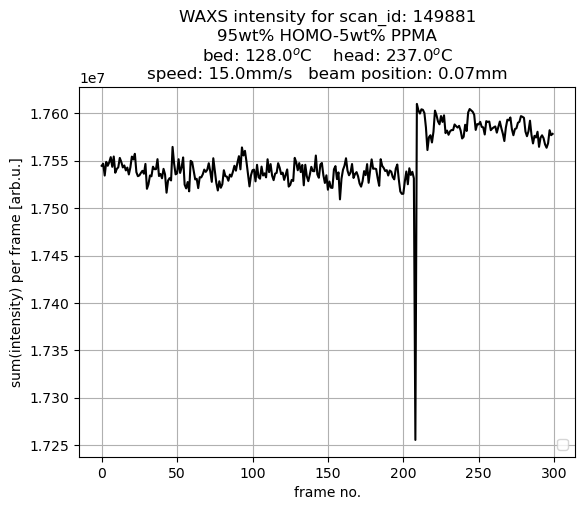

In [13]:
intensity_time = []
for i in range(np.shape(im[0])[0]):
    intensity_time.append(np.sum(im[0][i]))
intensity_time=np.array(intensity_time)

normalize=False
intensity_threshold=1000
max_frame = int(np.shape(im[0])[0]/1.2) # int or 'None'

if not type(max_frame) == int:
    max_frame=np.shape(im[0])[0]

mit=intensity_time>intensity_threshold

intensity_threshold2=np.nanmean(intensity_time[mit][1:6])

ind=intensity_time<intensity_threshold2
masked_intensity_time=deepcopy(intensity_time)
masked_intensity_time[ind]=np.nan

base_=min(intensity_time);norm_=max((intensity_time-base_))
base=0;norm=1
if normalize:
    base=min(intensity_time);norm=max((intensity_time-base))
else:
    base=0;norm=1
if insitu_waxs:
    xc = np.nanargmax(np.diff((masked_intensity_time[:max_frame]-base)/norm))
    print('frame at which the filament intersects the beam: %s'%xc)
    
# if insitu_waxs:
#     xc = np.nanargmax(np.diff((masked_intensity_time[:max_frame]-base)/norm))
    plt.plot([xc,xc],[min((intensity_time-base)/norm),max((intensity_time-base)/norm)],'r--',label='beam crossing filament:\nframe no.: %s -> %ss'%(xc,np.round(xc*frame_time,2)))
    plt.plot([0,len(intensity_time)],[(intensity_threshold2-base)/norm,(intensity_threshold2-base)/norm],'g--',label='intensity threshold \nfor background')
    
    ### not sure how well this method works for all data
    # xf_int=[]
    # ind1=t_int_x>16;ind2=t_int_x<20
    # for i in range(xc,len(t_int_y)):
    #     xf_int.append(sum(np.array(t_int_y[i])[ind1*ind2]))
    # xf = np.nanargmax(np.diff(xf_int[5:]))+10
    # try to calculate the shadow time instead
    
    mk1_shadow_length=16 # prinhead overhang that shadows part of the WAXS signal[mm]
    xf = int(np.round(mk1_shadow_length/print_speed/frame_time))
    plt.plot([xf+xc,xf+xc],[min((intensity_time-base)/norm),max((intensity_time-base)/norm)],'m--',label='no printhead shadow:\nframe no.: %s -> %ss'%(xf+xc,np.round((xf+xc)*frame_time,2)))
else: xc=0;xf=0
plt.plot((intensity_time-base)/norm,'k')
plt.legend(loc='lower right')
plt.ylabel('sum(intensity) per frame [arb.u.]');plt.xlabel('frame no.');plt.grid(True,which='both')
#plt.ylim(top=.75E7)
plt.title('WAXS intensity for scan_id: %s'%scan_list[0]+'\n%s'%exp_str)
fn = result_dir_full+'intensity_trace.png'
plt.savefig(fn);pdf_dict['intensity trace']=fn
if insitu_waxs:
    fig,ax=plt.subplots(1,3,figsize=(9,3))
    for ii,i in enumerate([-1,0,1]):
        plt.subplot(1,3,ii+1)
        plt.imshow(np.flipud(im[0][xc+i]))
        if i ==0: t0_str='[t$_0$]'
        else: t0_str=''
        plt.title('frame #%s %s'%(xc+i,t0_str))
    plt.tight_layout()
    fn = result_dir_full+'2D_images_filament_crossing_beam.png'
    plt.savefig(fn,bbox_inches = "tight");pdf_dict['2D_images_filament_crossing_beam']=fn
    fig,ax=plt.subplots(1,3,figsize=(9,3))
    for ii,i in enumerate([-1,0,1]):
        plt.subplot(1,3,ii+1)
        plt.imshow(np.flipud(im[0][xf+xc+i]))
        if i ==0: t0_str='no shadow'
        else: t0_str=''
        plt.title('frame #%s %s'%(xf+xc+i,t0_str))
    plt.tight_layout()
    fn = result_dir_full+'2D_images_end_of_shadow.png'
    plt.savefig(fn,bbox_inches = "tight");pdf_dict['2D_images_end_of_shadow']=fn
intensity_dict={'intensity trace':{'trace':intensity_time,'normalized trace':(intensity_time-base_)/norm_,'t0':xc,'xf':xf,'intensity_threshold':intensity_threshold,'normalized intensity_threshold':intensity_threshold/norm_}}

### create masks

no peak...trying step function...
automatic detection of platform shadow (py=237) seems reasonable...


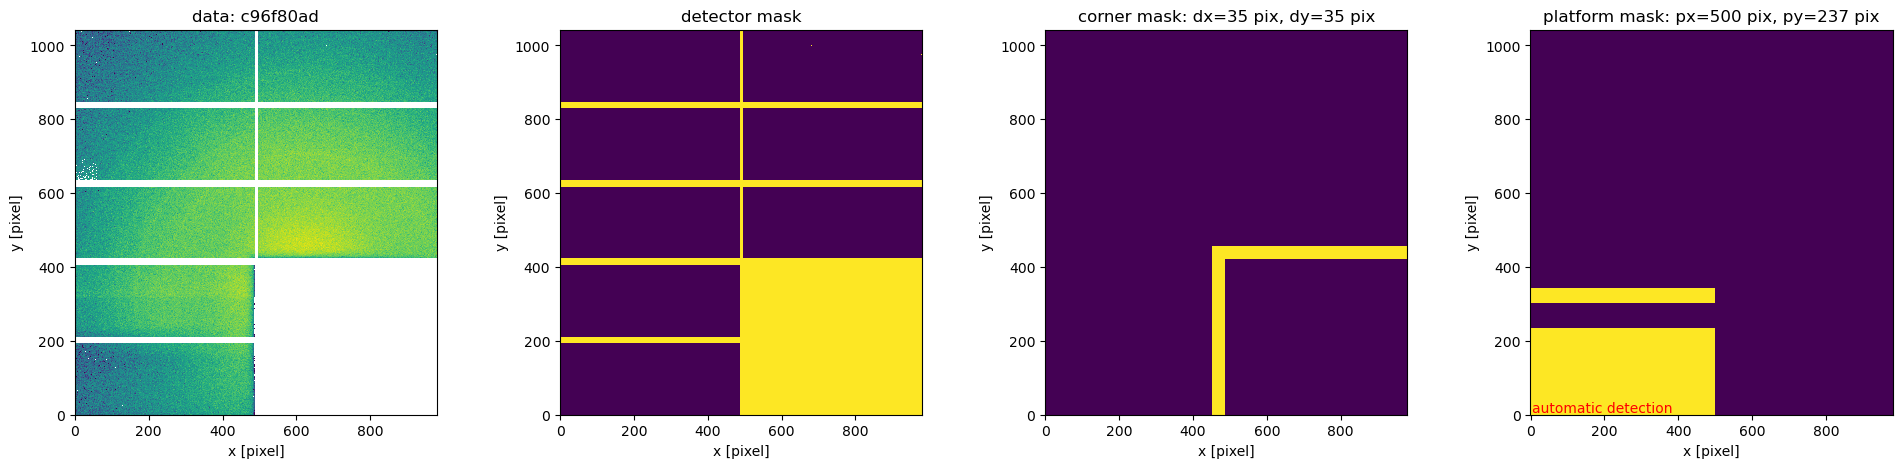

In [14]:
corner_masking = True # mask stripe of pixels with widht dx,dy around detector cutout
dx=35
dy=35
dy_min=20

platform_masking = True
automatic_shadow = True
flare_masking = True
flare_width=40
platform_dict = {0.07:{'px':500,'py':250},.25:{'px':500,'py':170},.4:{'px':500,'py':80}} # to be added for different heights, can do interpolation between existing values as well (need at least 3 values)
#platform_dict = {0.07:{'px':500,'py':150},.25:{'px':500,'py':140},.4:{'px':500,'py':15}}
#############################################################################################
# picking a random frame that's above the intensity threshold:
ind = intensity_dict['intensity trace']['normalized trace']>intensity_dict['intensity trace']['normalized intensity_threshold']
xcp=min([len(ind)-1,xc+10])
ind2=np.ones(len(ind),dtype=bool);ind2[0:xcp]=0;fr_ind=np.arange(0,len(ind))
img_nr = random.choice(fr_ind[ind*ind2])


img=np.flipud(im[0][img_nr])

fix,ax = plt.subplots(1,4,figsize=(24,5))
plt.subplot(1,4,1)
plt.imshow(img,norm='log',vmin=1,vmax=100)
plt.title('data: %s'%uid_list[0]);plt.xlabel('x [pixel]');plt.ylabel('y [pixel]')

mask = np.zeros(np.shape(img))
m = img<0
mask[m]=1
plt.subplot(1,4,2)
plt.imshow(mask)
plt.title('detector mask');plt.xlabel('x [pixel]');plt.ylabel('y [pixel]')

plt.subplot(1,4,3)
corner_mask=np.zeros(np.shape(mask))
if corner_masking:
    corner_mask[0:423+dx,487-dx:487]=1
    corner_mask[423:423+dy,487-dx:]=1
    plt.imshow(corner_mask);plt.title('corner mask: dx=%s pix, dy=%s pix'%(dx,dy));plt.xlabel('x [pixel]');plt.ylabel('y [pixel]')

plt.subplot(1,4,4)
platform_mask=np.zeros(np.shape(mask));flare_mask=np.zeros(np.shape(mask))
if flare_masking:
    try: # look if current platform hight is actually in the dictionary
        px=platform_dict[ref_md['beam position relative to platform']]['px']
    except: # if current platform hight is not in the dictionary, we'll need to inter/extra-polate from known values
        x=[]
        for i in platform_dict.keys():
            x.append(platform_dict[i]['px'])
        fx = interp1d(list(platform_dict.keys()),x,fill_value='extrapolate')
        px = int(max([0,min([fx(ref_md['beam position relative to platform']),config_dict['direct_beam_x']])]))    
    dby=int(config_dict['direct_beam_y'])
    flare_mask[int(dby-flare_width/2):int(dby+flare_width/2),0:px]=1
    
if automatic_shadow:
    try:
        min_int=.98
        y_range=int(np.round(config_dict['direct_beam_y']-flare_width/2))
        a=np.sum(im[0][xc+xf+200:,-y_range:,10:400],axis=2)
        b=np.sum(a,axis=0)
        fm=flare_mask[0:y_range,200]
        fm=np.array(fm,dtype=bool);fm=np.invert(fm)
        ind1=fm>0;ind2=b>10;ind=ind1*np.flipud(ind2)
        xrange=np.arange(len(b))
        b_=np.flipud(b)*fm
        p=ps(xrange[ind],b_[ind]);p_cen=int(np.round(p['CEN']))
        try:
            b_norm = np.average(nlargest(10,b_[ind][p_cen+50:p_cen+100]))
        except:
            b_norm = np.average(nlargest(10,b_[ind][p_cen:]))
        b_=b_/b_norm;b_=b_
        #plt.plot(xrange[ind],b_[ind],'.')
        b_in=interp1d(xrange[ind],b_[ind],kind='linear',fill_value='extrapolate')
        #plt.plot(xrange[ind],b_in(xrange[ind]),'r--')
        py=int(np.round(np.argmax(b_in(xrange[ind])>min_int))+0)
        # plt.plot([p['CEN'],p['CEN']],[0,1],'k--')
        # plt.plot([py,py],[0,1],'r--')

        # add some check to see if the solution is reasonable:
        if p['profile']=='step' and py > p['CEN'] and py < max(xrange[ind])-10:
            print('automatic detection of platform shadow (py=%s) seems reasonable...'%py)
            platform_shadow = 'automatic detection'
        else:
            print('automatic detection of platform shadow seems to have failed...falling back to interpolation from known values.')
            automatic_shadow=False
    except:
        print('automatic detection of platform shadow seems to have failed...falling back to interpolation from known values.')
        automatic_shadow=False
    
if platform_masking:
    try: # look if current platform hight is actually in the dictionary
        px=platform_dict[ref_md['beam position relative to platform']]['px']
    except: # if current platform hight is not in the dictionary, we'll need to inter/extra-polate from known values
        x=[]
        for i in platform_dict.keys():
            x.append(platform_dict[i]['px'])
        fx = interp1d(list(platform_dict.keys()),x,fill_value='extrapolate')
        px = int(max([0,min([fx(ref_md['beam position relative to platform']),config_dict['direct_beam_x']])]))
    # same for y:
    if not automatic_shadow:    # otherwise we get py from the code above   
        try: 
            py=platform_dict[ref_md['beam position relative to platform']]['py']
            platform_shadow = 'lookup table'
        except:
            y=[]
            for i in platform_dict.keys():
                y.append(platform_dict[i]['py'])
            fy = interp1d(list(platform_dict.keys()),y,fill_value='extrapolate')
            py = int(min([config_dict['direct_beam_y'],max([fy(ref_md['beam position relative to platform']),dy_min])])) # shadow cannot be higher than direct beam position and not lower than the detector (well, it can, but than it is not on the detector :-))      
            platform_shadow = 'interpolation'
    #platform_mask[0:py+dx,0:px]=1
    platform_mask[0:py,0:px]=1

plt.imshow(platform_mask+flare_mask);plt.title('platform mask: px=%s pix, py=%s pix'%(px,py));plt.xlabel('x [pixel]');plt.ylabel('y [pixel]')
if platform_masking:
    plt.text(5,5,platform_shadow,color='r')
fn = result_dir_full+'2D_images_mask.png'
plt.savefig(fn);pdf_dict['2D_images_mask']=fn
mask_=mask+corner_mask+platform_mask+flare_mask
ind = mask_>0
img_mask=np.ones(np.shape(mask_));img_mask[ind]=0

mask_dict={'detector_mask':{'mask':mask},'corner_mask':{'mask':corner_mask,'dx':dx,'dy':dy},'platform_mask':{'mask':platform_mask,'px':px,'py':py}}

### plot masked data

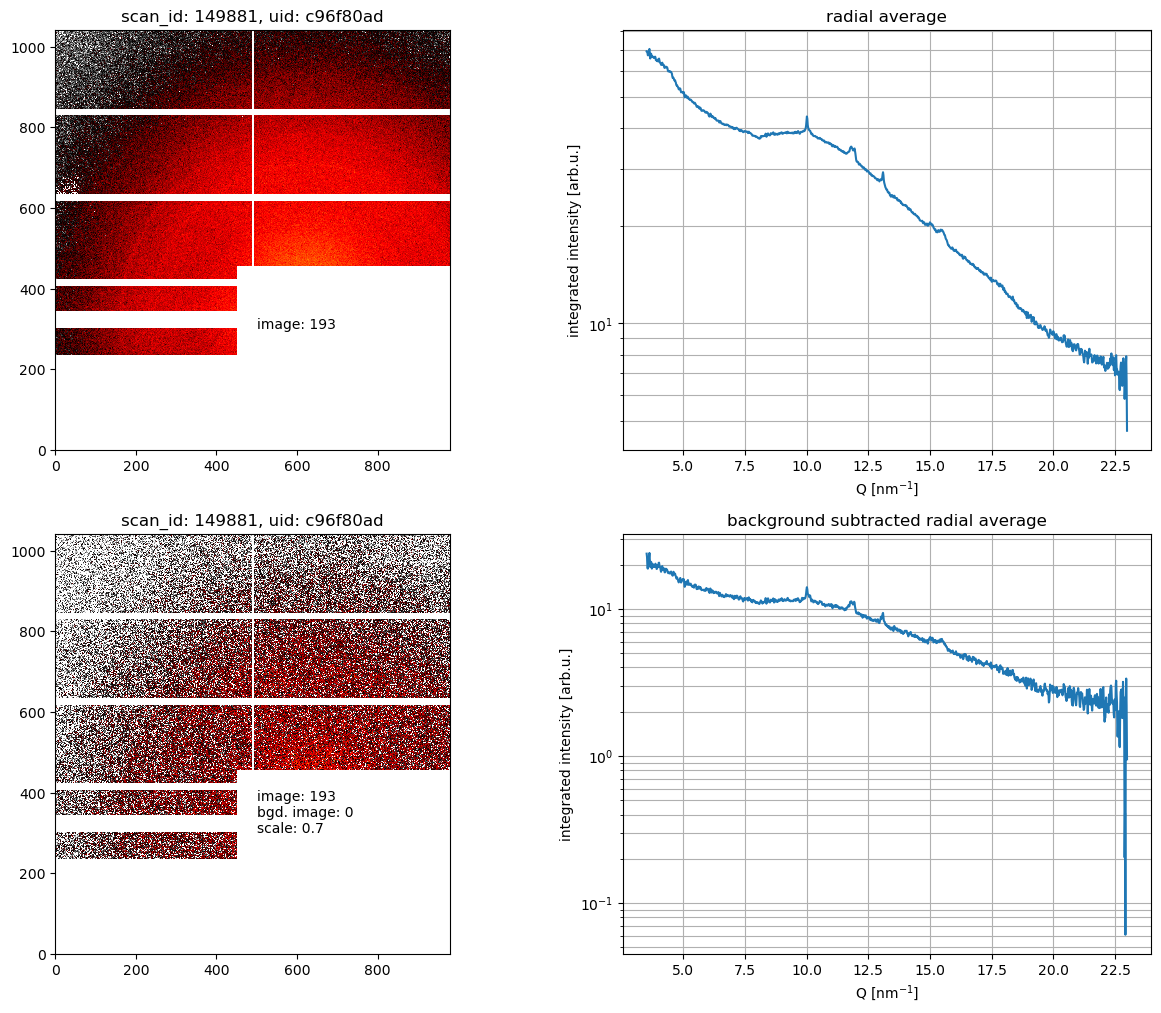

In [15]:
bg_nr=max([xc-2,0])
bg_scale=.7
#img_nr=xc+50

##############################################
img=np.flipud(im[0][img_nr])
bg_img = np.flipud(im[0][bg_nr])

fig,ax = plt.subplots(2,2,figsize=(15,12))
plt.subplot(2,2,1)
plt.imshow(img*img_mask,norm='log',vmin=2,vmax=200,cmap=cmap_albula)
plt.title('scan_id: %s, uid: %s'%(scan_list[0],uid_list[0]))
plt.text(500,300,'image: %s'%(img_nr));

plt.subplot(2,2,2)
azi = aintegrator.integrate1d((img),npt=1200,mask=mask_,unit="q_nm^-1")
plt.semilogy(azi[0],azi[1])
plt.xlabel('Q [nm$^{-1}$]');plt.ylabel('integrated intensity [arb.u.]')
plt.grid(True,which='both');plt.title('radial average')


plt.subplot(2,2,3)
plt.imshow((img-bg_img*bg_scale)*img_mask,norm='log',vmin=2,vmax=100,cmap=cmap_albula)
plt.title('scan_id: %s, uid: %s'%(scan_list[0],uid_list[0]))
plt.text(500,300,'image: %s\nbgd. image: %s\nscale: %s'%(img_nr,bg_nr,bg_scale));

plt.subplot(2,2,4)
azi = aintegrator.integrate1d((img-bg_img*bg_scale),npt=1200,mask=mask_,unit="q_nm^-1")
plt.semilogy(azi[0],azi[1])
plt.xlabel('Q [nm$^{-1}$]');plt.ylabel('integrated intensity [arb.u.]')
plt.grid(True,which='both');plt.title('background subtracted radial average')

plt.savefig(result_dir_full+'2D_1D_radial_average')

### calculate time-resolved radial integration

In [16]:
t_int_y=[]

unit="q_nm^-1"
for i in range(np.shape(im[0])[0]):
    img=np.flipud(im[0][i])
    azi = aintegrator.integrate1d(img,npt=1200,mask=mask_,unit=unit)
    t_int_y.append(azi[1])
t_int_x=azi[0]
bg_azi_int=np.average(t_int_y[xc-10:xc-2],axis=0)

radially_integrated_data_dict={'data':{'Q':t_int_x,'intensity':t_int_y,'Q_unit':unit},
                                      'background':{'Q':t_int_x,'intensity':bg_azi_int,'Q_unit':unit}}

### try to find onset of crystallization

In [17]:
frame_offset=10 # offset between two frames used for detecting onset of crystallization

peak_list=[10.060684  , 11.97553125, 13.16014013, 15.48067536] # most prominent peaks for PP
pw=.25
p_ind=np.zeros(len(t_int_x),dtype=bool)
for p in peak_list:
    ind1=t_int_x>p-pw;ind2=t_int_x<p+pw;ind=np.array(ind1*ind2)
    p_ind+=ind


#ind1=t_int_x>16;ind2=t_int_x<18;ind=ind1*ind2 # normalize the 'tail' intensity
ind1=t_int_x>10.5;ind2=t_int_x<11.5;ind=ind1*ind2 # normalize the intensity between first and second peak

kernel_size = 20
kernel = np.ones(kernel_size) / kernel_size


peak_intensities=[]
for i in range(len(t_int_y)-xc-xf-1-frame_offset):
    y_r = np.nanmean(t_int_y[xc+xf+i:xc+xf+i+frame_offset],axis=0)
    y_r = np.convolve(y_r, kernel, mode='same')
    y_r=y_r/np.nanmean(y_r[ind])
    y_f = np.nanmean(t_int_y[xc+xf+i+1:xc+xf+i+1+frame_offset],axis=0)
    y_f=y_f/np.nanmean(y_f[ind])
    y_f=np.convolve(y_f, kernel, mode='same')
    peak_intensities.append(sum(y_f[p_ind]/y_r[p_ind]))


In [18]:
# Note: because of the way bg is passed to the fit function as a static 'parameter', the function needs to be defined here...
def m_Voigt(x,a,b,c,d,e,f,g,bg):
    y=np.zeros(len(x))
    for i in range(len(a)):
        if i == 0:
            y+=pseudo_Voigt(x,a[i],b[i],c[i],d[i],e[i],f[i])
        else:
             y+=pseudo_Voigt(x,a[i],b[i],c[i],d[i],e=0,f=0)
    y+=g[0]*bg
    return y
    

def mm_Voigt(x,*C):
    s=int(len(C)/7)
    a=C[0:s];b=C[s:2*s];c=C[2*s:3*s];d=C[3*s:4*s];e=C[4*s:5*s];f=C[5*s:6*s];g=C[6*s:7*s]

    return m_Voigt(x,a,b,c,d,e,f,g,bg)


Rise of peak intensities:
R2: -0.844   chi_square_test: 0.000 -> critical value: 12.592
we're not sure whether crystallization happens within this dataset....trying it out!
frame_nr: 298  R2: 0.9995   peaks: [0.32289855 0.20434269 0.1009159  0.18469545 0.25699399]
frame_nr: 288  R2: 0.9995   peaks: [0.36608996 0.21857808 0.12539822 0.21806194 0.32543278]
frame_nr: 278  R2: 0.9995   peaks: [0.34862799 0.4062358  0.12511288 0.09834238 0.16289733]
frame_nr: 268  R2: 0.9996   peaks: [0.34727538 0.1994214  0.09869484 0.         0.35983773]
frame_nr: 258  R2: 0.9995   peaks: [0.33711649 0.23321386 0.12773321 0.16854021 0.15876349]
frame_nr: 248  R2: 0.9996   peaks: [0.31839532 0.20031235 0.13267449 0.19579732 0.16387984]
frame_nr: 238  R2: 0.9993   peaks: [0.30761226 0.33907412 0.09695889 0.14681672 0.26724749]
frame_nr: 228  R2: 0.9996   peaks: [0.29087016 0.2182592  0.08793909 0.13274716 0.19768033]
frame_nr: 218  R2: 0.9995   peaks: [0.3312092  0.20854881 0.08208291 0.10858859 0.13752456]

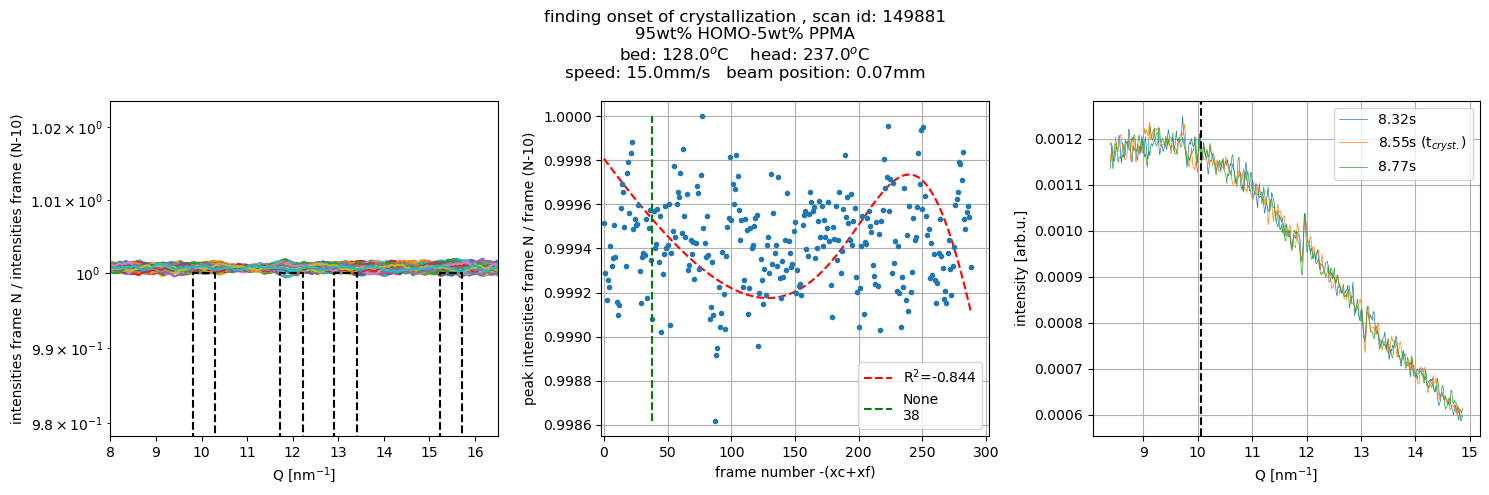

In [19]:
min_peak_height=.1 # minimum height of first peak to qualify as 'crystalline'

peak_intensities_norm=peak_intensities/max(peak_intensities)
nanind=np.isfinite(peak_intensities_norm)
x=np.arange(len(peak_intensities_norm))
#get estimate for peak:
kernel_size = 10 # convolution takes care of some outliers that might be present
kernel = np.ones(kernel_size) / kernel_size
psy=np.convolve(peak_intensities_norm-np.nanmean(peak_intensities_norm), kernel, mode='same')
a0=np.argmax(psy)
b0=np.nanmax(peak_intensities_norm)
c0=10
d0=.5
e0=np.nanmean(peak_intensities_norm)
f0=0
p0=[a0,b0,c0,d0,e0,f0]
bounds=([5,.9,5,0,0,-.1],[1E4,1.1,200,1,1,.1])
adj,p0,bounds=check_fit_conditioning(p0,bounds,adjust='start')
#### Control Fit Here: #####################################p0=[beta,Gamma,gamma,baseline]
#popt, pcov = curve_fit(pseudo_Voigt, x[:a0+2*bounds[1][2]],peak_intensities_norm[:a0+2*bounds[1][2]]  , p0= p0,bounds=bounds)
popt_peak_ratios, pcov = curve_fit(pseudo_Voigt, x[:a0+2*bounds[1][2]][nanind[:a0+2*bounds[1][2]]],peak_intensities_norm[:a0+2*bounds[1][2]][nanind[:a0+2*bounds[1][2]]]  , p0= p0,bounds=bounds)
#########################################################################################                
perr_peak_ratios = np.sqrt(np.diag(pcov))
r2_peak_ratios=np.round(R_2(peak_intensities_norm[:a0+2*bounds[1][2]][nanind[:a0+2*bounds[1][2]]],pseudo_Voigt(x[:a0+2*bounds[1][2]][nanind[:a0+2*bounds[1][2]]], *popt_peak_ratios)),4)

# should determine here whether the filament crystallized or not:
try: # this is not the most robust test...
    chi_square_test_statistic, p_value =stats.chisquare(peak_intensities_norm[:a0+2*bounds[1][2]][nanind[:a0+2*bounds[1][2]]],pseudo_Voigt(x[:a0+2*bounds[1][2]][nanind[:a0+2*bounds[1][2]]], *popt))
except: chi_square_test_statistic=0; p_value=0
null_hyp_crit = stats.chi2.ppf(1-0.05, df=6)

current_estimate=None;method=None;fine_method=None

print('Rise of peak intensities:\nR2: %.3f   chi_square_test: %.3f -> critical value: %.3f'%(r2_peak_ratios,chi_square_test_statistic,null_hyp_crit))
in_situ_crystallization=False;x_crystal=np.nan;crystallization_time=np.nan;intensity_plot_range=range(int(len(t_int_y)-xc-xf-1));rlim=None
iq_plot_range = np.linspace(xc+xf,len(t_int_y)-1,3,dtype=int)
crystallization_onset_dict={'in_situ_crystallization':in_situ_crystallization,'x_crystal':None,'method':None,'x_crystal unit':'frames','crystallization_time':None,'crystallization_time unit':'s',
                                    'peak_ratio_fit':{'data':peak_intensities_norm[:a0+2*bounds[1][2]],'x_offset':xc+xf,'R2':r2_peak_ratios,'chi2':chi_square_test_statistic,
                                    'fit_parameter':{'a':popt_peak_ratios[0],'b':popt_peak_ratios[1],'c':popt_peak_ratios[2],'d':popt_peak_ratios[3],'e':popt_peak_ratios[4],'f':popt_peak_ratios[5],
                                                     'a_err':perr_peak_ratios[0],'b_err':perr_peak_ratios[1],'c_err':perr_peak_ratios[2],'d_err':perr_peak_ratios[3],'e_err':perr_peak_ratios[4],'f_err':perr_peak_ratios[5],}}}

if r2_peak_ratios>.9 and chi_square_test_statistic < null_hyp_crit:  # that's the 'clear cut' case, however, x_crystal is still an estimate at this point -> check by fine fit around
    in_situ_crystallization=True;intensity_plot_range=range(int(2*popt_peak_ratios[2]))
    current_estimate= max([int(np.ceil(popt_peak_ratios[0]-0.5*popt_peak_ratios[2]+frame_offset/2))+xc+xf,xc+xf]) # estimate of frame at which crystallization occurs    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% definitition of crystallization frame %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
    rlim=a0+3*popt_peak_ratios[2] # limit for plotting fit of increasing peak intensities
    current_estimate_peak_ratios = current_estimate
    print("we're sure crystallization happens within this dataset, current estimate is frame #%s"%current_estimate)
else:
    current_estimate_peak_ratios=None
    print("we're not sure whether crystallization happens within this dataset....trying it out!")


# limit fitting range and get a background
q_start=8.3;q_end=16.5
ind1=t_int_x>=q_start;ind2=t_int_x<=q_end;ind=ind1*ind2
y_norm=np.nanmean(t_int_y[xf+xc+2:xf+xc+7],axis=0)
kernel_size = 20
kernel = np.ones(kernel_size) / kernel_size
y_norm = np.convolve(y_norm, kernel, mode='same')
bg=y_norm[ind]    

current_estimate=None
if not current_estimate: ###### getting an estimate of the potential crystallization onset: ###############################
    ppeak_fit_dict={}
    starting_values_,bounds_,pn=waxs_fit_setup('polypropylene',amplitude_scale=.1)
    starting_values=starting_values_
    frame_nr=np.shape(t_int_y)[0]-2
    int_ind = intensity_dict['intensity trace']['normalized trace'] > intensity_dict['intensity trace']['normalized intensity_threshold']
    popt_dict={}
    while frame_nr > xc+xf:  # going backwards, i.e. start at the most crystalline frame -if it exists- to help convergence
        if int_ind[frame_nr]:
            try:
                ###################################
                popt, pcov = curve_fit(mm_Voigt,t_int_x[ind],t_int_y[frame_nr][ind]  , p0= starting_values,  bounds=bounds_,ftol=1E-6,xtol=1E-8,method='dogbox')#,sigma=t_int_y[frame_nr][ind]**(0))
                ###################################
                perr = np.sqrt(np.diag(pcov))
                sperr = split_array(7,perr)
                r2=np.round(R_2(t_int_y[frame_nr][ind],mm_Voigt(t_int_x[ind], *popt)),4)
                # if r2>.9:
                #     starting_values = list(popt)
                # else: starting_values = starting_values_
                spopt=split_array(7,popt)
                ppeak_fit_dict[frame_nr]={'R2':r2,'peaks':spopt[1]}
                print('frame_nr: %s  R2: %s   peaks: %s'%(frame_nr,r2,spopt[1]))
                if spopt[1][0]<.05: frame_nr=-np.inf # early stop criterion
                popt_dict[frame_nr]=list(popt)
            except: pass
        frame_nr+=-10
    #### what did we get?
    peak_list_=[];consecutive=0;max_consecutive=1
    for i in ppeak_fit_dict.keys():
        peak_list_.append(ppeak_fit_dict[i]['peaks'][0])
        if ppeak_fit_dict[i]['R2']>.9 and ppeak_fit_dict[i]['peaks'][0]>min_peak_height:
            #peak_list_.append(ppeak_fit_dict[i]['peaks'][0])
            current_estimate=max([i,xc+xf]);consecutive+=1
            if consecutive>max_consecutive: max_consecutive=consecutive
        else: consecutive=0
    if min(peak_list_)>1: # -> peaks well developed in every frame we checked -> this is maybe a candidate for all_crystalline, but not for in_situ_crystallization
        print('No amplitudes of first peak <1: does NOT look like crystallization is happening within this dataset...maybe it is all crystalline. Do a fine check with peak ratios indicate in-situ crystallization')
    elif len(peak_list_)<5 and max_consecutive<3:
        print('%s course fits passed quality criteria, maximum number of consecutive fits that passed quality criteria: %s ...looks like this is maybe amorphous.'%(len(peak_list_),max_consecutive))
        current_estimate=None;method='coarse_check'
    print('we estimate the last frame (starting from end of dataset) to be crystalline: %s'%current_estimate)
    crystallization_onset_dict['coarse_check']={'pattern_fit_dict':ppeak_fit_dict}

if current_estimate:
    if not current_estimate_peak_ratios:
        current_estimate_peak_ratios=current_estimate
    ppeak_fit_dict={}
    starting_values_,bounds_,pn=waxs_fit_setup('polypropylene',amplitude_scale=.1)
    try:
        starting_values=popt_dict[current_estimate]
    except:
        starting_values=starting_values_
    for frame_nr in list(np.flipud(np.arange(max([xc+xf,min([current_estimate-10,current_estimate_peak_ratios-10])]),min([max([current_estimate+10,current_estimate_peak_ratios+10]),len(t_int_y)-1])))): # start fits from crystalline to non-crystalline -> easier to converge and then use popt as starting value
        if int_ind[frame_nr]: # making sure we're not fitting frames with 0 intensity
            try:
                ###################################
                popt, pcov = curve_fit(mm_Voigt,t_int_x[ind],t_int_y[frame_nr][ind]  , p0= starting_values,  bounds=bounds_,ftol=1E-6,xtol=1E-8,method='dogbox')#,sigma=t_int_y[frame_nr][ind]**(0))
                ###################################
                perr = np.sqrt(np.diag(pcov))
                sperr = split_array(7,perr)
                r2=np.round(R_2(t_int_y[frame_nr][ind],mm_Voigt(t_int_x[ind], *popt)),4)
                # if r2>.9:
                #     starting_values = list(popt)
                # else: starting_values = starting_values_
                spopt=split_array(7,popt)
                ppeak_fit_dict[frame_nr]={'R2':r2,'peaks':spopt[1]}
                print('frame_nr: %s  R2: %s   peaks: %s'%(frame_nr,r2,spopt[1]))
            except: ppeak_fit_dict[frame_nr]={'R2':-1,'peaks':list(0*np.arange(5))}
    crystallization_onset_dict['fine_check']={'pattern_fit_dict':ppeak_fit_dict}
    try: # try to get the crystallization onset from a linear fit of the 'fine search' (there is no reason the onset would be linear, but we're only looking at a few frames so linear might be a reasonable approximation)
        px=[];py=[];pr2=[] # prepping the data, trying to make sure we're not chasing noise...
        for p in  ppeak_fit_dict.keys():
            px.append(p);py.append(ppeak_fit_dict[p]['peaks'][0]);pr2.append(ppeak_fit_dict[p]['R2'])
        px=np.array(px);py=np.array(py);pr2=np.array(pr2)#;ind1=py>min_peak_height;ind2=pr2>.95;ind=ind1*ind2
        consecutive=0;max_consecutive=1;ind=[]
        for i in range(len(py)):
            if py[i]>min_peak_height and pr2[i]>.95 and consecutive<max_consecutive:
                ind.append(1);consecutive=0
            elif py[i]<min_peak_height:
                ind.append(0);consecutive+=1
            else: ind.append(0)
        ind=np.array(ind,dtype=bool) 

        fine_method=None
        if len(py[ind])>=2:
            # try linear fit first, limit to last 10 points to have a better chance things are actually linear
            try:
                popt, pcov = curve_fit(linear_intercept,px[ind][-10:],py[ind][-10:]-min_peak_height,p0=[.5,current_estimate],sigma=1/(pr2[ind][-10:]*py[ind][-10:]))
                perr=np.sqrt(np.diag(pcov))
                r2_lin=R_2(py[ind][-10:]-min_peak_height,linear_intercept(px[ind][-10:],*popt))
                SSS
                if r2_lin >.98 and len(py[ind])>2 and perr[1]<5:
                    current_estimate=max([int(np.round(popt[1])),xc+xf]);frame_err=perr[1];fine_method='linear_fit'
                elif r2_lin >.95 and len(py[ind])==2: # R2 is probably 1 in this case, but linear fit and linear interpolation should give the same result
                    current_estimate=max([int(np.round(popt[1])),xc+xf]);frame_err=np.nan;fine_method='linear_fit'
                if fine_method:
                    print('determining crystallization onset from fine check via linear fit, R2=%.3f  current estimate: frame #%s +/- %.1f'%(r2_lin,current_estimate,frame_err));method='fine_check'
                    crystallization_onset_dict['fine_check'][fine_method]={'peak_x':px[ind],'peak_y':py[ind],'peak_fit_r2':pr2[ind],'a':popt[0],'b':popt[1],'a_err':perr[0],'b_err':perr[1],'R2':r2_lin,'min_peak_height':min_peak_height}
            except:
                pass # if linear fit failed, we'll try interpolation
            # if linear fit failed or didn't yield a high fidelity result: try inter/extra-polation instead
            if not fine_method:
                try:
                    f_interp=interp1d(px[ind][-10:],py[ind][-10:],assume_sorted=False, kind='linear',fill_value='extrapolate')
                    r2_interp = R_2(py[ind][-10:],f_interp(px[ind][-10:]))
                    interp_est=fsolve(f_interp,min_peak_height,xtol=1E-3);interp_est=interp_est[0]
                    if r2_interp>.9 and np.abs(f_interp(interp_est))<1E-2:
                        current_estimate=max([int(np.round(interp_est)),xc+xf]);frame_err=np.nan;fine_method='interpolation';method='fine_check'
                        print('determining crystallization onset from fine check via interpolation, R2=%.3f  current estimate: frame #%s'%(r2_interp,current_estimate))
                        crystallization_onset_dict['fine_check'][fine_method]={'peak_x':px[ind],'peak_y':py[ind],'peak_fit_r2':pr2[ind],'px_interp':px[ind][-10:],'py_interp':f_interp(px[ind][-10:]),'b':interp_est,'b_err':frame_err,'R2':r2_interp,'min_peak_height':min_peak_height}
                    else:
                        coef = np.polyfit(px[ind][-10:],py[ind][-10:],1)
                        poly1d_fn = np.poly1d(coef)
                        est=(min_peak_height-coef[1])/coef[0]
                        if (est>max(px) or est <=0) and r2_peak_ratios<.9:
                            print('estimated onset of crystallization: frame #%s and R2 from peak ratio fit: %s -> this is NOT in-situ crystallization'%(int(np.round(est)),r2_peak_ratios))
                            current_estimate=None
                except:
                    pass
        if not fine_method: # both linear fit and inter/extra-polation failed or number of points obtained by fine check is <2 -> fall back to coarse check
            print('could NOT determine crystallization onset from fine check, take estimate from coarse check or "None" if this is not in-situ crystallization: %s'%current_estimate)
    except:
        method='coarse_check'
        print('could NOT determine crystallization onset from fine check, take estimate from coarse check: %s'%current_estimate)
        
############################################# SOME PLOTS  ##############################################################################  
if current_estimate:
    x_crystal_absolute=current_estimate
    x_crystal=int(np.round(current_estimate))-xc-xf
    crystallization_time = (xf+x_crystal)*frame_time # time (after filament crossing the X-ray beam) at which crystallization occurs
    iq_plot_range = range(xc+xf+x_crystal-1,xc+xf+x_crystal+2) 
    in_situ_crystallization = True
else: in_situ_crystallization = False;x_crystal_absolute=None

crystallization_onset_dict['in_situ_crystallization']=in_situ_crystallization
crystallization_onset_dict['x_crystal']=x_crystal
crystallization_onset_dict['x_crystal_absolute']=x_crystal_absolute
crystallization_onset_dict['crystallization_time']=crystallization_time
crystallization_onset_dict['method']=method

print('our best guess: in-situ crystallization = %s'%in_situ_crystallization)

if in_situ_crystallization:
    print('crystallization occured at frame #%s -> %ss after filament crossed the X-ray beam'%(xf+x_crystal,np.round(crystallization_time,2)))

img_num=3
if fine_method: img_num=4
fig,ax=plt.subplots(1,img_num,figsize=(int(5*img_num),5))
plt.subplot(1,img_num,1)
kernel_size = 20
kernel = np.ones(kernel_size) / kernel_size
ind1=t_int_x>10.5;ind2=t_int_x<11.5;ind=ind1*ind2 # normalize the intensity between first and second peak

intensity_plot_range=range(int(len(t_int_y)-xc-xf-frame_offset))

for i in intensity_plot_range:
        y_r = np.nanmean(t_int_y[xc+xf+i:xc+xf+i+frame_offset],axis=0)
        y_r = np.convolve(y_r, kernel, mode='same')
        y_r=y_r/np.nanmean(y_r[ind])
        y_f = np.nanmean(t_int_y[xc+xf+i+1:xc+xf+i+1+frame_offset],axis=0)
        y_f=y_f/np.nanmean(y_f[ind])
        y_f=np.convolve(y_f, kernel, mode='same')
        plt.semilogy(t_int_x,y_f/y_r)
plt.semilogy(t_int_x,p_ind,'k--')
plt.xlim(8,16.5)
plt.ylabel('intensities frame N / intensities frame (N-%s)'%frame_offset);plt.xlabel('Q [nm$^{-1}$]')

plt.subplot(1,img_num,2)
plt.plot(x,pseudo_Voigt(x, *popt_peak_ratios),'r--',label='R$^2$=%s'%r2_peak_ratios)
plt.plot(peak_intensities_norm,'.')
if current_estimate:
    plt.plot([x_crystal,x_crystal],[min(peak_intensities_norm),b0],'g--',label='%s\n%s'%(method,(current_estimate-xc-xf)))
ax=plt.gca();xl=ax.get_xlim();plt.xlim(max([xl[0],-2]),rlim)
plt.xlabel('frame number -(xc+xf)');plt.ylabel('peak intensities frame N / frame (N-%s)'%frame_offset);plt.legend();plt.grid(True)
# x_crystal= int(np.round(popt[0]-popt[2]))
# crystallization_time = (xf+x_crystal)*frame_time

plt.subplot(1,img_num,3)
for ii,i in enumerate(iq_plot_range):
    if ii==1 and in_situ_crystallization: cr_str='(t$_{cryst.}$)'
    else: cr_str=''
    plt.plot(t_int_x[300:700],(t_int_y[i][300:700]-bg_azi_int[300:700]*bg_scale)/sum(t_int_y[i]-bg_azi_int*bg_scale),linewidth=.5,label = '%ss %s'%(np.round((i-xc)*frame_time,2),cr_str))
ax=plt.gca();yl=ax.get_ylim()
plt.plot([peak_list[0],peak_list[0]],[yl[0],yl[1]],'k--')
plt.ylim(yl)
plt.legend()
plt.xlabel('Q [nm$^{-1}$]');plt.ylabel('intensity [arb.u.]');plt.grid(True)
    
if method == 'fine_check':
    plt.subplot(1,img_num,4)
    plt.plot(crystallization_onset_dict['fine_check'][fine_method]['peak_x'],crystallization_onset_dict['fine_check'][fine_method]['peak_y'],'o',fillstyle='none',color='C0',label='peak amplitude')
    if fine_method == 'linear_fit':
        plt.plot(crystallization_onset_dict['fine_check'][fine_method]['peak_x'],linear_intercept(crystallization_onset_dict['fine_check'][fine_method]['peak_x'],crystallization_onset_dict['fine_check'][fine_method]['a'],crystallization_onset_dict['fine_check'][fine_method]['b']),'g--',label='lin fit, R$^2$: %.2f'%(crystallization_onset_dict['fine_check'][fine_method]['R2']))
    elif fine_method == 'interpolation':
        plt.plot(crystallization_onset_dict['fine_check'][fine_method]['px_interp'],crystallization_onset_dict['fine_check'][fine_method]['py_interp'],'g--',label='interpol. R$^2$: %.2f'%crystallization_onset_dict['fine_check'][fine_method]['R2'])
    frame_err=crystallization_onset_dict['fine_check'][fine_method]['b_err']
    if not np.isnan(frame_err): frame_err=np.round(frame_err,1)
    plt.plot(current_estimate,crystallization_onset_dict['fine_check'][fine_method]['min_peak_height'],'md',label='cryst. onset: %s $\pm$ %s'%(current_estimate,frame_err))
    
    plt.legend(loc='center left');plt.xlabel('frame number');plt.ylabel('amplitude 1$^{st}$ peak');plt.grid(True)
    ax=plt.gca()
    ax2=plt.twinx(ax)
    ax2.plot(crystallization_onset_dict['fine_check'][fine_method]['peak_x'],crystallization_onset_dict['fine_check'][fine_method]['peak_fit_r2'],'+',color='C1')
    ax2.set_ylim(.85,1.01);ax2.set_ylabel('R$^2$ peak fit',color='C1')   

plt.suptitle('finding onset of crystallization , scan id: %s\n'%scan_list[0]+exp_str)
plt.tight_layout()
fn = result_dir_full+'crystallization_onset.png'
plt.savefig(fn,bbox_inches = "tight");pdf_dict['crystallization_onset']=fn

In [20]:
if not in_situ_crystallization: # IF crystallization doesn't occur within the dataset, is the whole dataset crystalline?
    
    peak_list=[10.060684  , 11.97553125, 13.16014013, 15.48067536] # most prominent peaks for PP; treat the double peak at high Q as one peak
    pw_list=[.2,.2,.2,.5]
    peak_fraction_threshold = np.array([.66,.66,.5,.05])
    
    norm_int_threshold = intensity_dict['intensity trace']['normalized intensity_threshold']
    norm_intensity_trace = intensity_dict['intensity trace']['normalized trace']

    p_limit_list=[np.array(peak_list)-np.array(pw_list),np.array(peak_list)+np.array(pw_list)]
    norm_peak_height_threshold = 2 # threshold for peak detection -> data is normalized so that the background should be ~1
    peaks_found_list=np.zeros(len(peak_list))
    all_crystalline=False
    
    h_list = [2,1,.5,.25] # peak heights to test for, using scipy find_peaks
    
    for k in range(len(t_int_y)):
        if norm_intensity_trace[k]>norm_int_threshold:
            y=t_int_y[k]
            y1=np.nanmean(y[100:150]);x1=t_int_x[125]
            y2=np.nanmean(y[-150:-100]);x2=t_int_x[-125]
            
            m=(y2-y1)/(x2-x1);c=y1-x1*m
            in1=t_int_x>7.5;in2=t_int_x<17;ind=in1*in2
            bg_all_cryst = (c+t_int_x*m) # need this later for peak fitting
            
            ## we're not sure how hight the peaks will be above the background -> try different peak heights and see if we get a resonable number of peaks
            peak_number_ok=False
            for ph in h_list:
                if peak_number_ok == False:
                    p = find_peaks(y[ind]/(c+t_int_x[ind]*m),height=ph)
                    if len(p[0])>0 and len(p[0])<10: peak_number_ok = True

            if len(p[0])<10: # don't want a noisy pattern with a hundred 'peaks'
                pl=[]
                for pp in p[0]:
                    q=t_int_x[ind][pp]
                    ind1=q>p_limit_list[0];ind2=q<p_limit_list[1]
                    if sum(ind1*ind2)>0:
                        h=np.argmax(ind1*ind2)
                        if h not in pl: # make sure we identify each peak only once/frame (for the double peak it'll be sufficient to detect one of the two)
                            peaks_found_list[h]+=1
                            pl.append(h)
    peaks_found_list_normalized = peaks_found_list/sum((norm_intensity_trace)>norm_int_threshold)
    if sum((peaks_found_list_normalized) > peak_fraction_threshold)>3:
        all_crystalline=True
        print('Our best guess: material is crystalline throughout the dataset')
    else:
        print('Our best guess: material is amorphous throughout the dataset')
    all_crystalline_dict={'all_crystalline':all_crystalline,'peak_list':peak_list,'peak_width_list':pw_list,'norm_peak_height_threshold':norm_peak_height_threshold,'norm_int_threshold':norm_int_threshold,'peak_fraction_threshold':peak_fraction_threshold,
                          'peaks_found_list':peaks_found_list,'peaks_found_list_normalized':peaks_found_list_normalized}

    plt.plot(peak_list,peaks_found_list_normalized,'ko',fillstyle='none')
    for pp,p in enumerate(peak_list):
        lab=None
        if pp == 0:
            lab='threshold for whole\ndataset crystalline'
        plt.plot([p_limit_list[0][pp],p_limit_list[1][pp]],[peak_fraction_threshold[pp],peak_fraction_threshold[pp]],'--',color='C2',label=lab)
    plt.xlabel('peak position (Q [nm$^{-1}$])');plt.ylabel('fraction of dataset peak has been detected');plt.grid(True)
    plt.title('checking whether whole dataset is crystalline , scan id: %s\n'%scan_list[0]+exp_str);plt.legend()
    #plt.tight_layout()
    fn = result_dir_full+'all_crystalline.png'
    plt.savefig(fn,bbox_inches = "tight");pdf_dict['all_crystalline']=fn
else: all_crystalline_dict={};all_crystalline=False

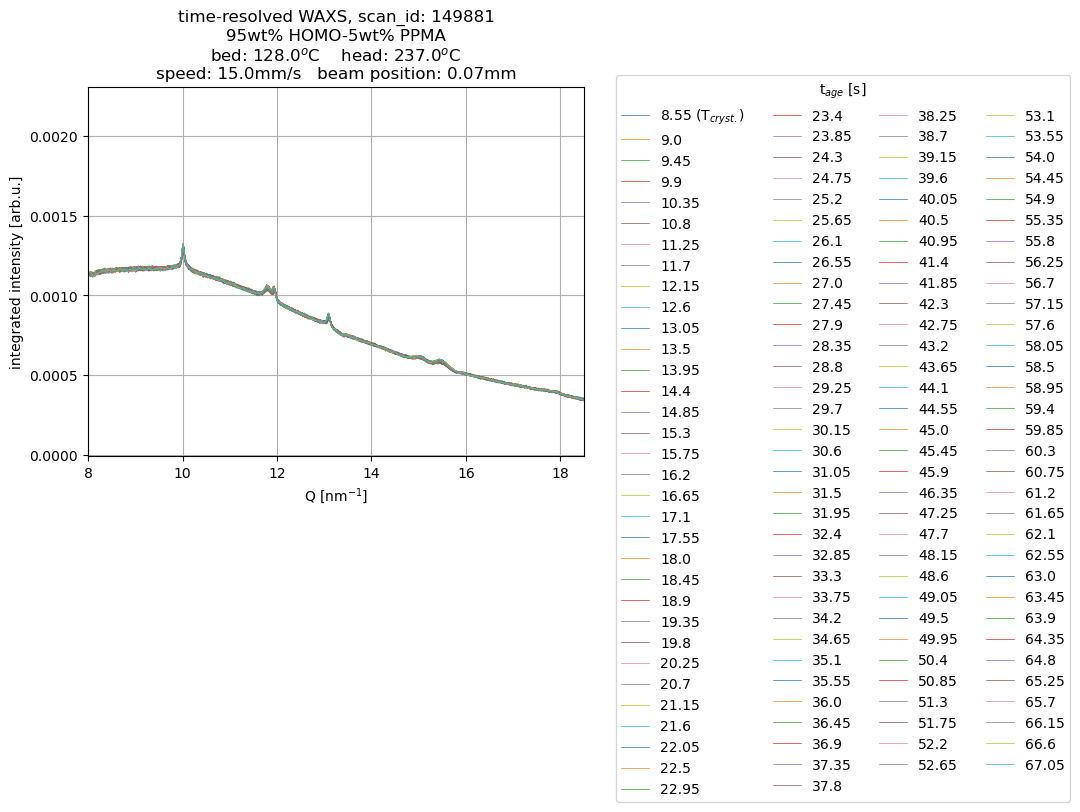

In [21]:
bg_scale=0


int_ind = intensity_dict['intensity trace']['normalized trace'] > intensity_dict['intensity trace']['normalized intensity_threshold']
if in_situ_crystallization:
    #step=2;plot_range = range(xc+xf+x_crystal,xc+xf+x_crystal+int(min([popt[0]+4*popt[2],len(t_int_y)])),step)
    step=2;plot_range = range(xc+xf+x_crystal,int(min([xc+xf+x_crystal+4*crystallization_onset_dict['peak_ratio_fit']['fit_parameter']['c'],len(t_int_y)-1])),step)
else:    plot_range = np.linspace(xc+xf,len(t_int_y)-1,25,dtype=int)

for ii,i in enumerate(plot_range):
    if int_ind[i]:
        tc_label=''
        if in_situ_crystallization:
            if i == xc+xf+x_crystal:
                tc_label=' (T$_{cryst.}$)'
            plt.semilogy(t_int_x,(t_int_y[i]-bg_azi_int*bg_scale)/sum(t_int_y[i]-bg_azi_int*bg_scale),linewidth=.5,label = '%s'%(np.round((i-xc)*frame_time,2))+tc_label)
        else:
            plt.semilogy(t_int_x,t_int_y[i],linewidth=.5,label = '%s'%(np.round((i-xc)*frame_time,2))+tc_label)

plt.xlabel('Q [nm$^{-1}$]');plt.ylabel('integrated intensity [arb.u.]')
plt.grid(True,which='both')
plt.xlim(8,18.5)
plt.yscale('linear')#;plt.ylim(bottom=0,top=16)
plt.legend(title='t$_{age}$ [s]',loc='upper left',bbox_to_anchor=(1.05,1.05),ncol=4);
plt.title('time-resolved WAXS, scan_id: %s'%scan_list[0]+'\n%s'%exp_str)
#plt.tight_layout()
fn = result_dir_full+'timeseries_I_Q.png'
plt.savefig(fn,bbox_inches = "tight");pdf_dict['timeseries_I_Q']=fn

### create some 'background' prior to crystallization

In [22]:
if in_situ_crystallization:
    y_norm=np.nanmean(t_int_y[x_crystal+xf+xc-5:x_crystal+xf+xc-2],axis=0)
    kernel_size = 20
    kernel = np.ones(kernel_size) / kernel_size
    y_norm = np.convolve(y_norm, kernel, mode='same')
elif all_crystalline:
    y_norm = bg_all_cryst

### fit peaks

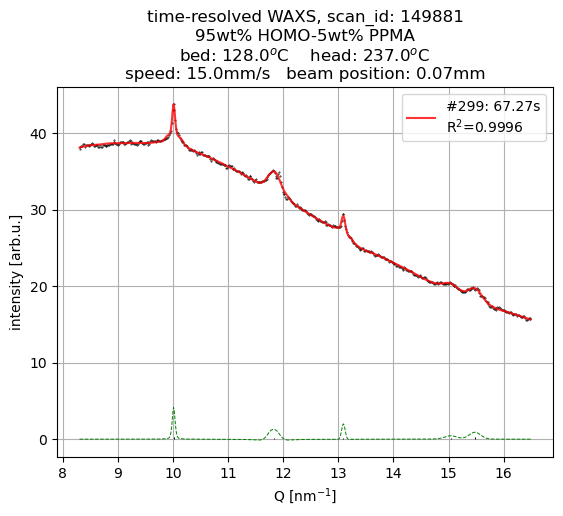

fitting progress: 100%|██████████| 262/262 [33:51<00:00,  4.85s/frames]

total elapsed time for fitting: 2031.4s


In [23]:
early_stop=0 # number of dataframes to skip at the end

first_frame=0
if in_situ_crystallization:
    first_frame=xc+xf+x_crystal

if in_situ_crystallization or all_crystalline:
    if in_situ_crystallization: amplitude_scale=.1 # for in-situ crustallization need to start with small peak amplitudes
    else: amplitude_scale=1
    
    # limit fitting range
    q_start=8.3;q_end=16.5
    ind1=t_int_x>=q_start;ind2=t_int_x<=q_end;ind=ind1*ind2
    bg=y_norm[ind]
    
    # get sensible starting values and bounds for fit
    starting_values_,bounds_,pn=waxs_fit_setup('polypropylene',amplitude_scale=amplitude_scale)
    starting_values = starting_values_
     # create a scaling vecor highlighing peak areas
    v=np.zeros(len(t_int_x[ind]))
    for ppp,pp in enumerate(starting_values_[:pn]):
        vw=bounds_[1][2*pn:3*pn][ppp]
        vind1=t_int_x[ind]<pp+vw;vind2=t_int_x[ind]>pp-vw;vind=vind1*vind2
        v+=vind
    vind1=v<1;v[vind1]=.4;vind2=v>1;v[vind2]=1
    
    
    last_successful =  starting_values_
    peak_fit_dict={}
    tr=time.time()
    progress_bar = tqdm(total=len(range(first_frame,len(t_int_y)-early_stop)),desc='fitting progress',unit='frames',nrows=20)
    display(clear=True,wait =True)
    
    sigma_=None
    for frame_nr in range(first_frame,len(t_int_y)-early_stop):    
        if int_ind[frame_nr]: # make sure this is not a zero intensity frame, e.g. because the shutter was closed           
            if all_crystalline: # create linear background between first and last peak in list
                xg=[];yg=[]
                for o in [0,len(peak_list)-1]:
                    bgind1=t_int_x<peak_list[o]-1
                    bgind2=t_int_x>peak_list[o]-1-.5
                    bgin1=bgind1*bgind2
                    xg.append(np.nanmean(t_int_x[bgind1*bgind2]))
                    yg.append(np.nanmean(y_norm[bgind1*bgind2]))
                y1=yg[0];y2=yg[1];x1=xg[0];x2=xg[1]
                m=(y2-y1)/(x2-x1);c=y1-x1*m
                #in1=t_int_x>q_start;in2=t_int_x<q_end;ind=in1*in2
                in1=t_int_x>7.5;in2=t_int_x<17;ind=in1*in2
                bg = (c+t_int_x[ind]*m) # need this later for peak fitting
                sigma_=t_int_y[frame_nr][ind]
            try: del popt # if fit fails (e.g. didn't converge) it will not return popt and plot will show parameters of last successful fit
            except: pass
            try:
                p0=starting_values_;converged=False;temp_result={}
                for i in range(3):
                    if i==0: sigma=sigma_
                    else: sigma=None
                    if i==1: p0=popt # try to continue from previous
                    elif i==2: p0=last_successful # try parameters from last successful fit
                    if not converged:
                        ###################################
                        popt, pcov = curve_fit(mm_Voigt,t_int_x[ind],t_int_y[frame_nr][ind]  , p0= p0,  bounds=bounds_,ftol=1E-6,xtol=1E-8,method='dogbox',sigma=sigma)
                        ###################################
                        r2=np.round(R_2(t_int_y[frame_nr][ind],mm_Voigt(t_int_x[ind], *popt)),4)
                        temp_result[r2]=(popt,pcov)
                        if r2>.995:
                            converged=True                       
                popt,pcov = temp_result[max(temp_result.keys())]
                r2=max(temp_result.keys())
                if r2>.95:
                    last_successful=popt
                perr = np.sqrt(np.diag(pcov))
                sperr = split_array(7,perr)
                spopt=split_array(7,popt)
            except: sperr = np.nan*np.ones(np.shape(split_array(7,starting_values_)));spopt =np.nan*np.ones(np.shape(split_array(7,starting_values_)));r2=-1 # in case the fit fails
        else: sperr = np.nan*np.ones(np.shape(split_array(7,starting_values_)));spopt = np.nan*np.ones(np.shape(split_array(7,starting_values_)));r2=-1 # in case intensity in the frame is 0

        peak_fit_dict[frame_nr]={'time':(frame_nr-xc)*frame_time,'q_start':q_start,'q_end':q_end,'fit_index':ind,'Q':t_int_x[ind],'bg':bg,'peak_num':len(spopt[0]),'R2':r2,'a':spopt[0],'b':spopt[1],'c':spopt[2],'d':spopt[3],'e':spopt[4],
                                 'f':spopt[5],'g':spopt[6],'param_definitions':{'a':'center','b':'amplitude','c':'fwhm','d':'mixing','e':'constant offset',
                                                                               'f':'slope','g':'background scale'},
                                'a_err':sperr[0],'b_err':sperr[1],'c_err':sperr[2],'d_err':sperr[3],'e_err':sperr[4],'f_err':sperr[5],'g_err':sperr[6]}
        if plotting and int_ind[frame_nr]:
            display(clear=True,wait =True)
            plt.title('time-resolved WAXS, scan_id: %s'%scan_list[0]+'\n%s'%exp_str)
            plt.plot(t_int_x[ind],t_int_y[frame_nr][ind],'k.',markersize=.8)
            try: # this will fail if the fit failed
                plt.plot(t_int_x[ind],mm_Voigt(t_int_x[ind],*popt),'r-',alpha=.8,label='#%s: %ss\nR$^2$=%s'%(frame_nr,np.round((frame_nr-xc)*frame_time,2),r2))
                plt.legend();plt.ylabel('intensity [arb.u.]');plt.xlabel('Q [nm$^{-1}$]');plt.grid(True)
                ### peaks without background
                sa = split_array(7,popt)
                for i in range(4,7):
                    sa[i]=np.zeros(len(sa[i]))
                popt_=np.array(sa).flatten().tolist()
                plt.plot(t_int_x[ind],mm_Voigt(t_int_x[ind],*popt_),'g--',linewidth=.7)
                sa_=split_array(7,popt_)
                for i in range(pn):
                    plt.plot([sa_[0][i],sa_[0][i]],[0,sa_[1][i]],'k--',linewidth=.7)
            except: pass
            display(plt.gcf())
            plt.close()
        progress_bar.update()
    print('total elapsed time for fitting: %.1fs'%(time.time()-tr))
else: peak_fit_dict=None

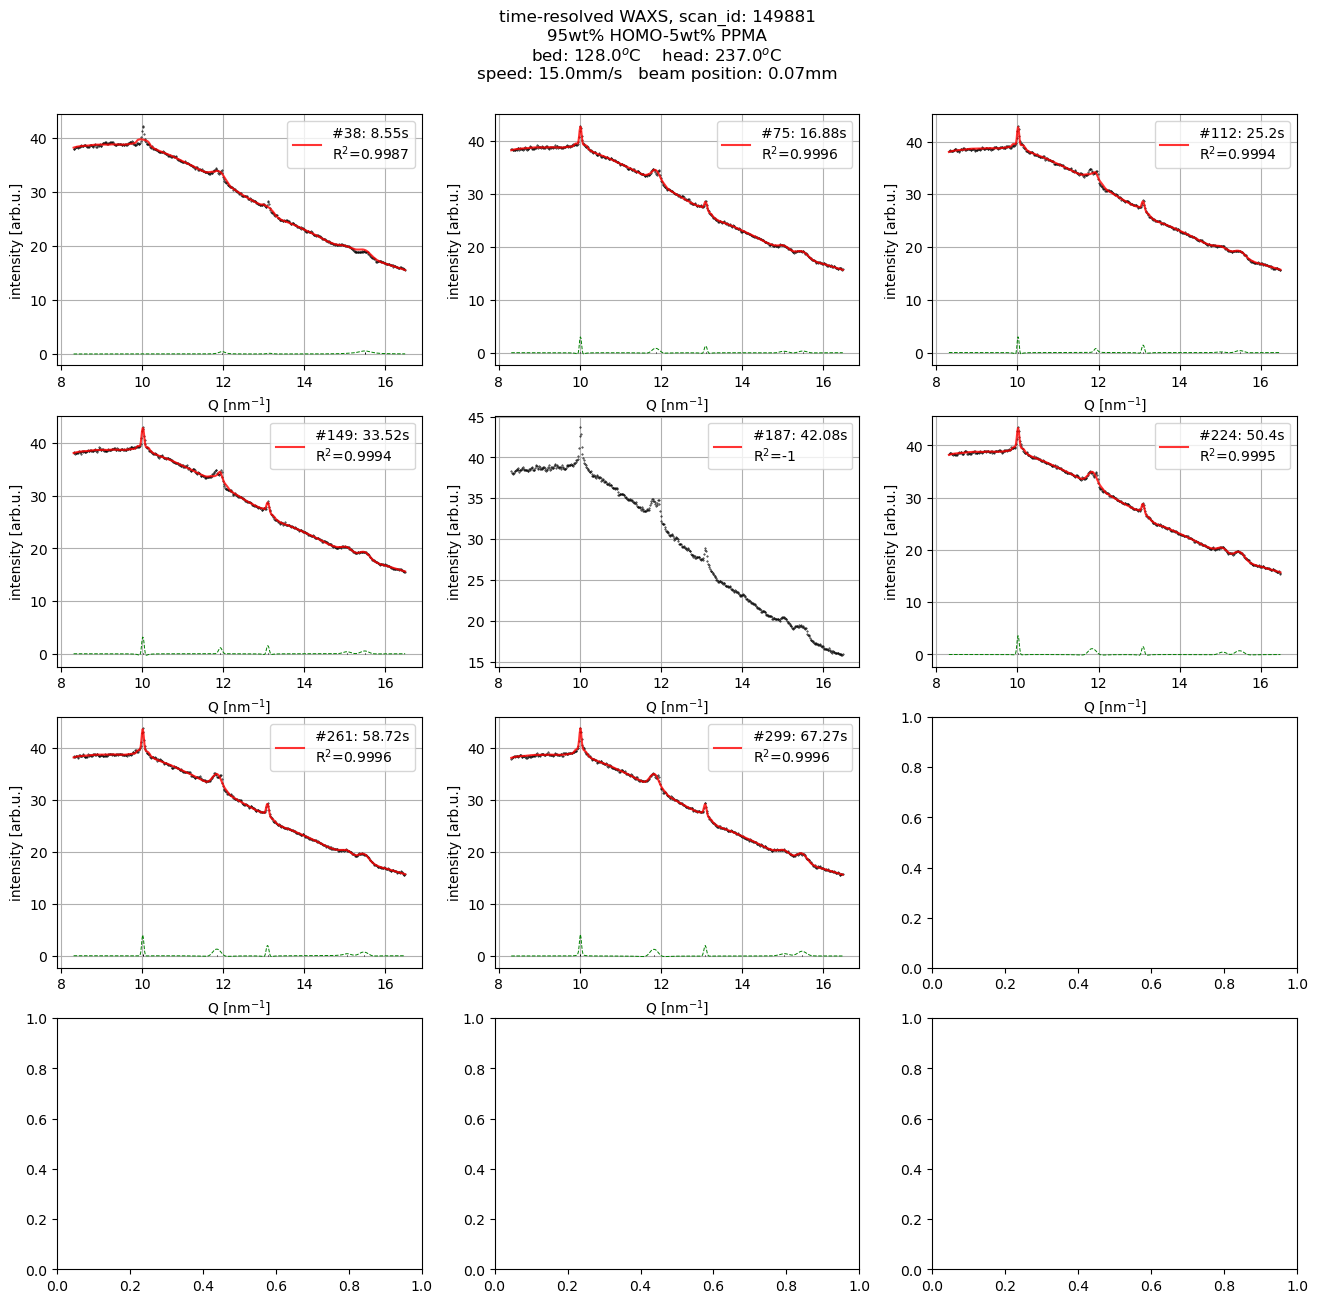

In [24]:
if in_situ_crystallization or all_crystalline:
    if in_situ_crystallization: # -> 8 plots for the initial crystallization
        a=np.linspace(max([xc+xf+x_crystal,0]),min([int(xc+xf+x_crystal+3*crystallization_onset_dict['peak_ratio_fit']['fit_parameter']['c']),ref_md['pil800k_imnum']-1]),8,dtype=int)
        b=np.linspace(min([max([int(xc+xf+x_crystal+3*crystallization_onset_dict['peak_ratio_fit']['fit_parameter']['c']),0]),ref_md['pil800k_imnum']-1]),ref_md['pil800k_imnum']-1,5,dtype=int)[1:]
        plot_list = sorted(list(set(np.concatenate((a,b)))))
    else: plot_list = np.linspace(1,ref_md['pil800k_imnum']-1,12,dtype=int)
    fig,ax = plt.subplots(4,3,figsize=(16,15))
    plt.suptitle('time-resolved WAXS, scan_id: %s'%scan_list[0]+'\n%s'%exp_str,y=.95)
    #if  in_situ_crystallization:
    for pp,p in enumerate(plot_list):
        if int_ind[p]:
            plt.subplot(4,3,pp+1)
            params=np.array([peak_fit_dict[p]['a'],peak_fit_dict[p]['b'],peak_fit_dict[p]['c'],peak_fit_dict[p]['d'],peak_fit_dict[p]['e'],peak_fit_dict[p]['f'],peak_fit_dict[p]['g']]).flatten()
            plt.plot(peak_fit_dict[p]['Q'],np.array(radially_integrated_data_dict['data']['intensity'][p])[peak_fit_dict[p]['fit_index']],'k.',markersize=.8)
            plt.plot(peak_fit_dict[p]['Q'],mm_Voigt(peak_fit_dict[p]['Q'],*params),'r-',alpha=.8,label='#%s: %ss\nR$^2$=%s'%(p,np.round(peak_fit_dict[p]['time'],2),peak_fit_dict[p]['R2']))
            params_=np.array([peak_fit_dict[p]['a'],peak_fit_dict[p]['b'],peak_fit_dict[p]['c'],peak_fit_dict[p]['d'],np.zeros(len(peak_fit_dict[p]['a'])),np.zeros(len(peak_fit_dict[p]['a'])),np.zeros(len(peak_fit_dict[p]['a']))]).flatten()
            plt.plot(peak_fit_dict[p]['Q'],mm_Voigt(peak_fit_dict[p]['Q'],*params_),'g--',linewidth=.7)
            for i in range(len(peak_fit_dict[p]['a'])):
                 plt.plot([peak_fit_dict[p]['a'][i],peak_fit_dict[p]['a'][i]],[0,peak_fit_dict[p]['b'][i]],'k--',linewidth=.7)
            plt.legend();plt.ylabel('intensity [arb.u.]');plt.xlabel('Q [nm$^{-1}$]');plt.grid(True)
    fn = result_dir_full+'fit_examples_I_Q.png'
    plt.savefig(fn,bbox_inches = "tight");pdf_dict['fit_examples_I_Q']=fn

In [25]:
if in_situ_crystallization or all_crystalline:
    kl=['center','height','fwhm'];dl=['a','b','c']
    fr=list(peak_fit_dict.keys())
    r2_list=[]
    for f in fr:
        r2_list.append(peak_fit_dict[f]['R2'])
    pn=peak_fit_dict[fr[0]]['peak_num']
    peak_dict={}
    for p in range(pn):
        peak_dict[p+1]={'time':[]}
        for k in kl:
            peak_dict[p+1][k]=[]
            peak_dict[p+1][k+'_err']=[]
    for f in fr:
        for p in range(pn):
            peak_dict[p+1]['time'].append(peak_fit_dict[f]['time'])
            for kk,k in enumerate(kl):
                peak_dict[p+1][k].append(peak_fit_dict[f][dl[kk]][p])
                peak_dict[p+1][k+'_err'].append(peak_fit_dict[f][dl[kk]+'_err'][p])
else: peak_dict=None

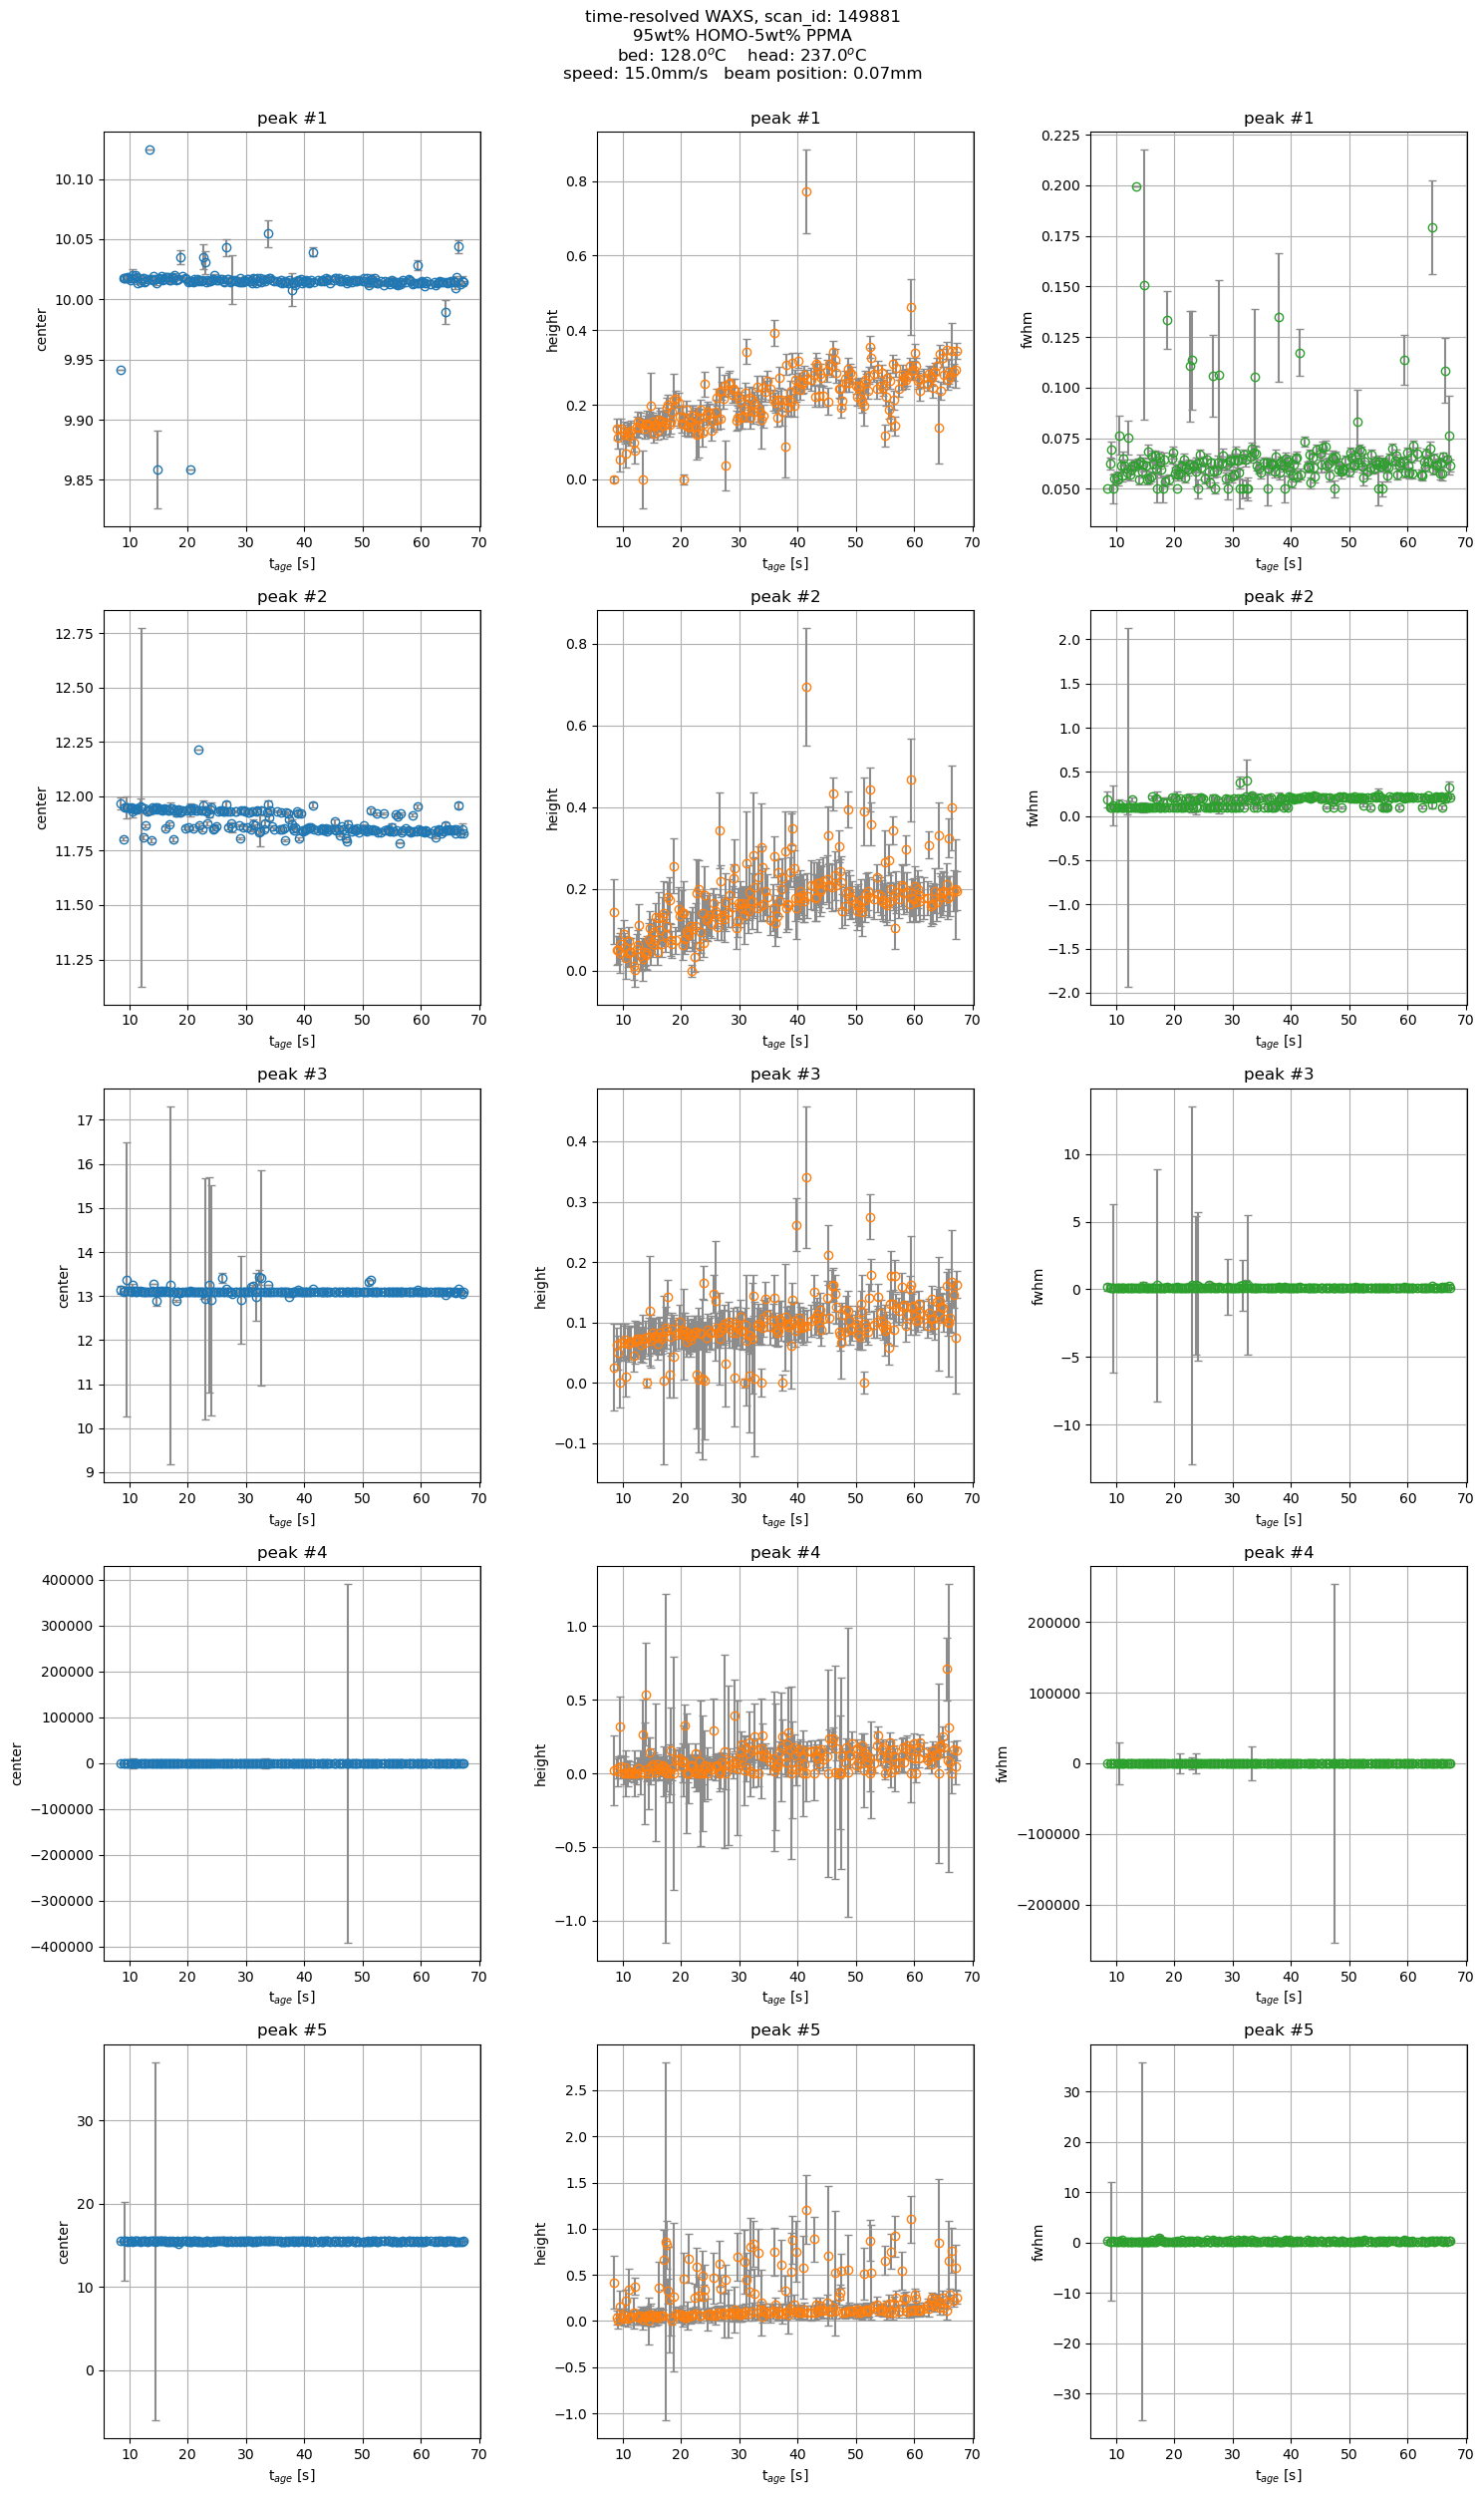

In [26]:
r2_thresh = .97

if in_situ_crystallization or all_crystalline:
    r2_ind = np.array(r2_list)>=r2_thresh
    fig,ax=plt.subplots(pn,3,figsize=(15,5*pn))
    pc=1
    for n in list(peak_dict.keys()):
        for kk,k in enumerate(kl):
            ni=1
            if k == 'height':
                ni=intensity_dict['intensity trace']['normalized trace'][first_frame:]
                #ni=norm_int[xc+xf+x_crystal:]
            plt.subplot(pn,3,pc);pc+=1;plt.title('peak #%s'%n)
            plt.errorbar(np.array(peak_dict[n]['time'])[r2_ind],(np.array(peak_dict[n][k])/ni)[r2_ind], yerr=(np.array(peak_dict[n][k+'_err'])/ni)[r2_ind], xerr=None,fmt='o',color='C%s'%kk ,mfc='none',ecolor='.55', elinewidth=None, capsize=3, 
                                     barsabove=False, lolims=False, uplims=False, xlolims=False, xuplims=False, errorevery=1, capthick=None)   
            plt.ylabel(k);plt.xlabel('t$_{age}$ [s]');plt.grid(True)
    plt.suptitle('time-resolved WAXS, scan_id: %s'%scan_list[0]+'\n%s'%exp_str,y=1.0)
    plt.tight_layout()
    fn = result_dir_full+'I_Q_fit_parameters.png'
    plt.savefig(fn,bbox_inches = "tight");pdf_dict['I_Q_fit_parameters']=fn

### check last frame for $\Phi$-dependence

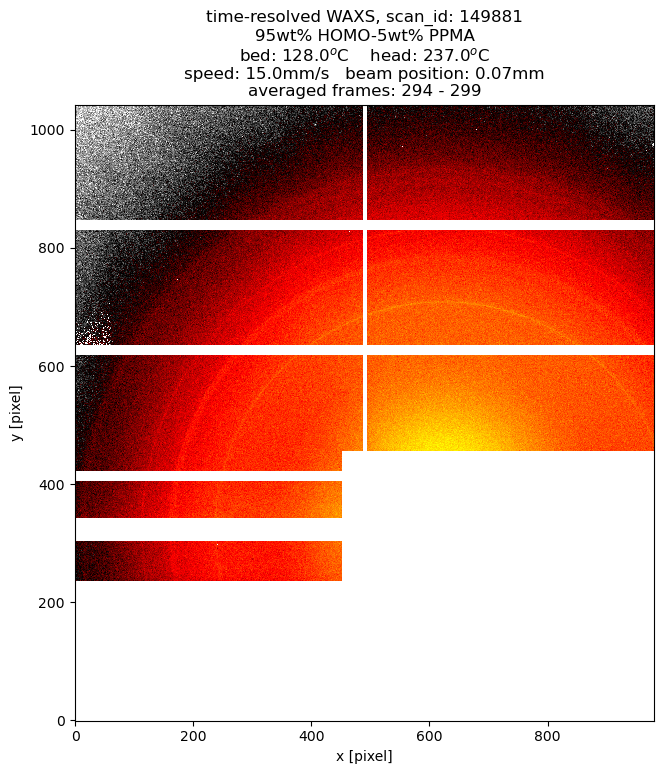

In [27]:
average_num=5 # number of frames to average for better statistics

### last frame with intensity:
ind = intensity_time < intensity_threshold#*1E4
intensity_time_=deepcopy(intensity_time)
intensity_time_[ind]=0;intensity_time_[np.invert(ind)]=1
last_frame = len(intensity_time)-np.argmax(np.flipud(intensity_time_))-1

yim=np.flipud(np.nanmean(im[0][last_frame-average_num:last_frame],axis=0))
fig,ax = plt.subplots(figsize=(8,8))
hist = np.histogram(yim*img_mask)
bc = (hist[1][:-1] + hist[1][1:]) / 2
plt.imshow(yim*img_mask,norm='log',vmin=bc[0],vmax=bc[-1],cmap=cmap_albula) # this tries auto-scaling for intensity
plt.title('time-resolved WAXS, scan_id: %s'%scan_list[0]+'\n%s'%exp_str+'\naveraged frames: %s - %s'%((last_frame-average_num),last_frame));plt.xlabel('x [pixel]');plt.ylabel('y [pixel]')
fn = result_dir_full+'2D_image_averaged_end_of_series.png'
plt.savefig(fn,bbox_inches = "tight");pdf_dict['2D_image_averaged_end_of_series']=fn

using inpainting for phi-map: True


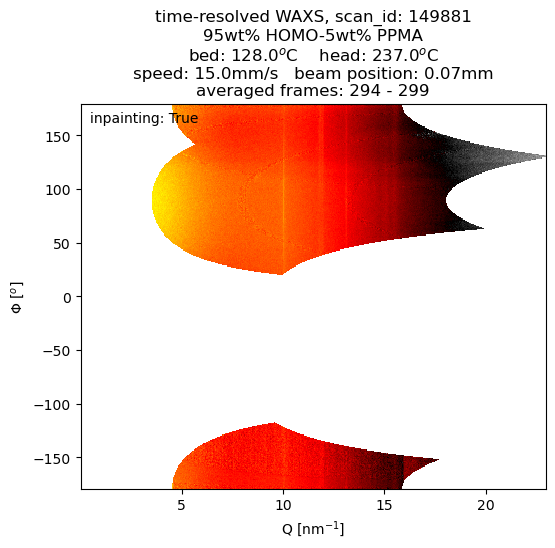

In [28]:
#inpainting = True # paint in detector mask gaps before creating phi_map
print('using inpainting for phi-map: %s'%inpainting)

if inpainting:
    quadrant_mask = np.zeros(np.shape(mask))
    quadrant_mask[0:423,487:]=1
    infill_mask=quadrant_mask+corner_mask+platform_mask+flare_mask
    ind=infill_mask>.1;infill_mask[ind]=1
    ind = infill_mask==np.nan
    infill_mask[ind]=1
    d2_img = aintegrator.inpainting(yim, mask=mask_, poissonian=True) 
    d2_mask = corner_mask+quadrant_mask
else:
    d2_img=yim
    d2_mask = mask_

mmethod=[]
for m in IntegrationMethod.select_method(dim=2):
    mmethod.append(m)
    

phi_map=aintegrator.integrate2d(d2_img, npt_rad=1200, npt_azim=360,mask=d2_mask,unit="q_nm^-1", method=mmethod[3],polarization_factor=1) #_legacy gets the old behavior with large gaps or method[3,4]

fig,ax = plt.subplots(figsize=(6,5))
plt.imshow(phi_map[0],norm='log',extent=[phi_map[1][0], phi_map[1][-1], phi_map[2][0],phi_map[2][-1]],cmap=cmap_albula)
ax=plt.gca()
ax.set_aspect('auto')
plt.xlabel('Q [nm$^{-1}$]');plt.ylabel('$\Phi$ [$^o$]')
plt.title('time-resolved WAXS, scan_id: %s'%scan_list[0]+'\n%s'%exp_str+'\naveraged frames: %s - %s'%((last_frame-average_num),last_frame))
plt.text(0.02, .98, 'inpainting: %s'%inpainting, horizontalalignment='left',verticalalignment='top', transform=ax.transAxes)

phi_map_dict={'ave_img':yim,'ave_start_frame':last_frame-average_num,'ave_end_frame':last_frame,'phi_map':[phi_map[0],phi_map[1],phi_map[2]],'inpainting':inpainting}
fn = result_dir_full+'phi_map_averaged_end_of_series.png'
plt.savefig(fn,bbox_inches = "tight");pdf_dict['phi_map_averaged_end_of_series']=fn

### integrate fitted peaks (or amorphous ring) over FWHM

using centro-symmetry for phi-cuts: True


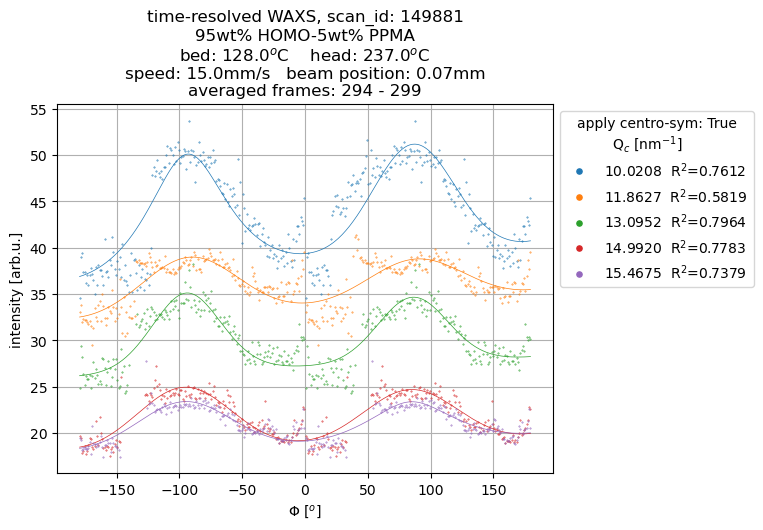

In [29]:
#use_centrosymmetry = True # if True: filling in as much of the missing data from the corresponding datapoint at +/-180deg
print('using centro-symmetry for phi-cuts: %s'% use_centrosymmetry)

if in_situ_crystallization or all_crystalline:
    for n in range(peak_fit_dict[last_frame]['peak_num']):
        pc=[];pw=[];t=[]
        for i in range(last_frame-average_num,last_frame+1):
            pc.append(peak_fit_dict[i]['a'][n]);pw.append(peak_fit_dict[i]['c'][n])
            t.append(peak_fit_dict[i]['time'])

        pc=np.nanmean(pc);pw=np.nanmean(pw);t=np.nanmean(t)
        ind1=phi_map[1]>pc-pw/2;ind2=phi_map[1]<pc+pw/2;ind=ind1*ind2
        m=np.ones(np.shape(phi_map[0]))
        for k in range(np.shape(m)[0]):
            m[k,:]=m[k,:]*ind

        kernel_size = 1
        kernel = np.ones(kernel_size) / kernel_size
        phi_cut = np.nanmax(m*phi_map[0],axis=1)
        I_phi=convolve1d(phi_cut,kernel, mode='wrap')
        x=phi_map[2]+180
        if use_centrosymmetry:
            for ii,i in enumerate(I_phi):
                if i == 0.:       
                    if x[ii] + 180 <= 360:
                        if min(np.abs(x-(x[ii] + 180))) < 1:
                            xind=np.argmin(np.abs(x-(x[ii] + 180)))
                            I_phi[ii]=I_phi[xind]
                    elif x[ii] + 180 > 360:
                        if min(np.abs(x-(x[ii] - 180))) < 1:
                            xind=np.argmin(np.abs(x-(x[ii] - 180)))
                            I_phi[ii]=I_phi[xind]
        
        ### add fitting here:
        b=np.nanmean(nsmallest(int(len(x)*.05),I_phi))
        m=np.nanmean(nlargest(int(len(x)*.05),I_phi-b))
        y=(I_phi-b)/m

        ## need an estimate for the peak -> smooth first (if not done already) to avoid running for an outlier...
        if kernel_size <10:
            kernel_size = 1 # convolution takes care of some outliers that might be present
            kernel = np.ones(kernel_size) / kernel_size
            psy=np.convolve(y, kernel, mode='same')
        else: psy=y
        a0=np.argmax(psy)
        if a0 > 180:
            a0=a0-180
        #p0=[a0,50,60,.5,0,0,50,60,.0]
        #b0=([0,0.1,5,0,-.05,-.001,0,5,0],[180,1000,90,1,.05,.001,1000,900,100])
        #p0=[a0,30,60,.5,.24,0,30,60,.5]
        b0=([0,0.1,5,0,-.05,-.001,0,5,0],[180,1000,90,1,2,.001,1000,90,1])
        null_ind = I_phi!=0
        #p0=[a0,30,60,.5,np.nanmean(y[null_ind]),0,30,60,.5]
        p0=[a0,30,60,.5,np.nanmean(y),0,30,60,.5]
        #try:
        out_ind = np.invert(is_outlier(y[null_ind]))
        ###################################
        popt, pcov = curve_fit(phi_test_Voigt,x[null_ind][out_ind],y[null_ind][out_ind]  , p0=p0,  bounds=b0,ftol=1E-8,xtol=1E-8,method='trf',sigma=y[null_ind][out_ind]**(0))
        ###################################
        perr = np.sqrt(np.diag(pcov))
        yf=phi_test_Voigt(x, *popt)*m+b
        r2=np.round(R_2(I_phi[null_ind][out_ind],yf[null_ind][out_ind]),4)
        if r2 >.2:
            plt.plot(x-180,yf,linewidth=.5,color='C%s'%n)
        #except: popt=np.ones(len(p0))*np.nan;perr=np.ones(len(p0))*np.nan;r2=-1

        ####
        plt.plot(phi_map[2][null_ind],I_phi[null_ind],'.',markersize=.75,color='C%s'%n,label='%.4f  R$^2$=%s'%(pc,r2))

        if n == 0:
            phi_cut_dict={'time':t,'Phi':phi_map[2],'use_centrosymmetry':use_centrosymmetry,'cuts':{n:{'Q':pc,'I_phi':I_phi,'R2':r2}}}
        else:
            phi_cut_dict['cuts'][n]={'Q':pc,'I_phi':I_phi,'R2':r2}
else:
    n=0 # for plot color
    pc=10.2;pw=1;t=frame_time*(last_frame-xc)
    ind1=phi_map[1]>pc-pw/2;ind2=phi_map[1]<pc+pw/2;ind=ind1*ind2
    m=np.ones(np.shape(phi_map[0]))
    for k in range(np.shape(m)[0]):
        m[k,:]=m[k,:]*ind

    kernel_size = 1
    kernel = np.ones(kernel_size) / kernel_size
    phi_cut = np.nanmax(m*phi_map[0],axis=1)
    I_phi=convolve1d(phi_cut,kernel, mode='wrap')
    
    x=phi_map[2]+180
    if use_centrosymmetry:
        for ii,i in enumerate(I_phi):
            if i == 0.:       
                if x[ii] + 180 <= 360:
                    if min(np.abs(x-(x[ii] + 180))) < 1:
                        xind=np.argmin(np.abs(x-(x[ii] + 180)))
                        I_phi[ii]=I_phi[xind]
                elif x[ii] + 180 > 360:
                    if min(np.abs(x-(x[ii] - 180))) < 1:
                        xind=np.argmin(np.abs(x-(x[ii] - 180)))
                        I_phi[ii]=I_phi[xind]
    ### add fitting here:
    b=np.nanmean(nsmallest(int(len(x)*.05),I_phi))
    m=np.nanmean(nlargest(int(len(x)*.05),I_phi-b))
    y=(I_phi-b)/m

    ## need an estimate for the peak -> smooth first (if not done already) to avoid running for an outlier...
    if kernel_size <10:
        kernel_size = 10 # convolution takes care of some outliers that might be present
        kernel = np.ones(kernel_size) / kernel_size
        psy=np.convolve(y, kernel, mode='same')
    else: psy=y
    a0=np.argmax(psy)
    if a0 > 180:
        a0=a0-180
    p0=[a0,50,60,.5,0,0,50,60,.5]
    b0=([0,0.1,40,0,-.05,-.001,0,5,0],[180,1000,90,1,2,.001,1000,90,1])
    null_ind = I_phi!=0
    try:
        #null_ind = I_phi==0
        ###################################
        popt, pcov = curve_fit(phi_test_Voigt,x[null_ind],y[null_ind]  , p0=p0,  bounds=b0,ftol=1E-8,xtol=1E-8,method='trf',sigma=y[null_ind]**(0))
        ###################################

        perr = np.sqrt(np.diag(pcov))
        yf=phi_test_Voigt(x, *popt)*m+b
        r2=np.round(R_2(I_phi[null_ind],yf[null_ind]),4)
        if r2 <.2:
            plt.plot(x-180,yf,linewidth=.5,color='C%s'%n)
    except: popt=np.ones(len(p0))*np.nan;perr=np.ones(len(p0))*np.nan;r2=-1
    
    plt.plot(phi_map[2][null_ind],I_phi[null_ind],'.',markersize=.75,color='C%s'%n,label='%.4f  R$^2$=%s'%(pc,r2))
    phi_cut_dict={'time':t,'Phi':phi_map[2],'cuts':{1:{'Q':pc,'I_phi':I_phi,'R2':r2}}}

plt.legend(title='apply centro-sym: %s\n        Q$_c$ [nm$^{-1}$]'%use_centrosymmetry,loc='upper left',bbox_to_anchor=(1,1.0),markerscale=10);plt.xlabel('$\Phi$ [$^o$]');plt.ylabel('intensity [arb.u.]');plt.grid(True)
plt.title('time-resolved WAXS, scan_id: %s'%scan_list[0]+'\n%s'%exp_str+'\naveraged frames: %s - %s'%((last_frame-average_num),last_frame))
fn = result_dir_full+'phi_cuts_averaged_end_of_series.png'
plt.savefig(fn,bbox_inches = "tight");pdf_dict['phi_cuts_averaged_end_of_series']=fn

### Save Results (requires saving = True!!!)

In [30]:
sfn='waxs_analysis_uid=%s.pkl'%ref_md['pil800k_uid']
res_dir = result_dir+'%s/'%(ref_md['pil800k_uid'])

save_dict={'detector_calibration': config_dict,'meta_data': ref_md,'total_intensity': intensity_dict,
'masks':mask_dict,'radially_integrated_data': radially_integrated_data_dict,'crystallization_onset':crystallization_onset_dict, 'all_crystalline_dict':all_crystalline_dict,
'peak_fitting':peak_fit_dict,'peaks':peak_dict,'phi_map':phi_map_dict,'phi_cuts': phi_cut_dict }
print('IF True, results from this notebook would be saved in %s as %s'%(result_dir+'%s/'%ref_md['pil800k_uid'],sfn))
if True:
    os.makedirs(res_dir, exist_ok=True)
    save_pickle(res_dir+'%s'%sfn,save_dict,verbose=True);sfn=res_dir+'%s'%sfn
else: sfn=False

IF True, results from this notebook would be saved in /nsls2/data/chx/legacy/analysis/2024_2/lwiegart/Results/c96f80ad-6441-4d45-b492-32223b8fb088/ as waxs_analysis_uid=c96f80ad-6441-4d45-b492-32223b8fb088.pkl
Data has been saved to file: /nsls2/data/chx/legacy/analysis/2024_2/lwiegart/Results/c96f80ad-6441-4d45-b492-32223b8fb088/waxs_analysis_uid=c96f80ad-6441-4d45-b492-32223b8fb088.pkl


In [31]:
### How to load the data again:
# uid_full = '87f46651-4cac-40e1-9805-ab64e6b184ea'
# analyst = 'lwiegart' # this determines in which directory the data will be saved
# cycle = '2024_2'
# fn=_base_path_+cycle+'/'+analyst+'/'+'Results/%s/waxs_analysis_uid=%s'%(uid_full,uid_full)
# save_dict = load_pickle(fn, verbose=True)

### Create PDF Report

In [32]:
if create_pdf_report:
    sys.path.insert(0, "/nsls2/data/chx/shared/CHX_Software/packages/pdf_reports/")
    import pdf_reports
    from pdf_reports import make_mixmd_table, capture_calibration, WAXS_ANALYSIS_PDF_REPORT
    fn = make_mixmd_table(ref_md,path=result_dir+'%s/'%(ref_md['pil800k_uid']),plot=False)
    pdf_dict['dataset']=fn
    
    fn = capture_calibration(aintegrator,cfilepath,path=result_dir+'%s/'%(ref_md['pil800k_uid']),plot=False)
    pdf_dict['calibration']=fn
    
    pdf_filename = 'WAXS_analysis_uid_%s.pdf'%ref_md['pil800k_uid']
    WAXS_ANALYSIS_PDF_REPORT(res_dir, pdf_filename, pdf_dict, save_dict, sfn)

/nsls2/data/chx/shared/CHX_Software/packages/pdf_reports/pdf_reports.py:48: UserWarning: Glyph 120524 (\N{MATHEMATICAL BOLD SMALL LAMDA}) missing from current font.
  plt.savefig(fn,format='png',dpi=150, bbox_inches='tight')


### Attach PDF report to Olog

In [33]:
if create_pdf_report:
    success=False;i=0
    while not success and i<5:
        try:
            i+=1
            update_olog_uid_with_file(uid_list[0][:6], text='Add WAXS Data Processing Report', 
                                      filename=res_dir+ pdf_filename, append_name='_R%s'%i )
            success=True
            print("Successfully upated Olog entry for uid: %s with report %s"%(uid_list[0],res_dir+ pdf_filename))
        except:
            print("Failed to attach PDF report to Olog...")
        if i> 5:
            success=True

Append _R1 to the filename.
Failed to attach PDF report to Olog...
Append _R2 to the filename.
Failed to attach PDF report to Olog...
Append _R3 to the filename.
Failed to attach PDF report to Olog...
Append _R4 to the filename.
Failed to attach PDF report to Olog...
Append _R5 to the filename.
Failed to attach PDF report to Olog...


#### 